In [1]:
import rascontrol
import numpy as np
import os
import glob
import yaml
from datetime import datetime, timedelta
import pandas as pd
import math
from scipy.interpolate import interp1d
from shutil import copyfile
import tqdm
import re
# Dds file
from pydsstools.heclib.dss import HecDss
from pydsstools.core import TimeSeriesContainer,UNDEFINED
import matplotlib.pyplot as plt
import os
import seaborn as sns
import sys
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import shutil
sns.set_theme()

import warnings

# Desactivar todas las advertencias
warnings.filterwarnings("ignore")

In [2]:
def Modificar_U(path_project, name_project, Fichero, rainfall_plan_name):
    
    """Función para modificar fichero de lluvias en HEC-RAS"""
    
    # Leer fichero TXT original
    # ..............................................................................
    # Leer el archivo TXT original
    with open(path_project + name_project+'.u'+'{:02d}'.format(5), 'r') as file:
        lineas = file.readlines()

    # Buscar palabras para ordenar dataframe
    # ...............................................................................
    palabra_buscada = 'Point_'
    indices = [i for i, linea in enumerate(lineas) if palabra_buscada in linea][10:]

    # General lista con el orden en el que están metidas las estaciones

    lista_cadenas = []
    for i in indices:
        lista_cadenas.append(lineas[i])

    # Expresión regular para encontrar "TS Name=Point_<n>"
    patron = re.compile(r'TS Name=(Point_\w+)')

    # Lista para almacenar las palabras extraídas
    palabras_extraidas = []

    # Iterar sobre la lista de cadenas
    for cadena in lista_cadenas:
        match = patron.search(cadena)
        if match:
            palabra_extraida = match.group(1)
            palabras_extraidas.append(palabra_extraida)
    
    # Ruta al archivo CSV con los nuevos datos
    # ..............................................................................
    ruta_up = 'Output/Hietogramas/Return_period/Up/'+Fichero
    ruta_down = 'Output/Hietogramas/Return_period/Down/'+Fichero
    # Leer los nuevos datos desde el archivo CSV
    Up = pd.read_csv(ruta_up, index_col = 0)
    Down = pd.read_csv(ruta_down, index_col = 0)
    nuevos_datos = pd.concat([Up, Down], axis = 1)
    nuevos_datos.reset_index(inplace = True, drop= True)
    # Reorganizar las columnas del DataFrame en el nuevo orden
    nuevos_datos = nuevos_datos[palabras_extraidas]
    
    # Crear diccionario datos de estaciones ordenadas y con estructura HEC RAS
    # ..............................................................................    
    celdas_por_columna = {}
    # Iterar sobre las columnas del DataFrame
    for columna in nuevos_datos.columns:
        celdas_transformadas = []

        # Iterar sobre las filas del DataFrame con incrementos de 2
        for i in range(0, len(nuevos_datos.index), 2):
            P1 = nuevos_datos.loc[i, columna]
            P2 = nuevos_datos.loc[i+1, columna]

            # Construir la celda transformada
            celda_transformada = f'              0.     {P1:.9f}             0.     {P2:.9f}\n'

            # Agregar la celda transformada a la lista
            celdas_transformadas.append(celda_transformada)

        # Guardar la lista de celdas transformadas en el diccionario
        celdas_por_columna[columna] = celdas_transformadas
    # Calcular los indices
    celda_a_buscar = 'Met BC=Precipitation|TS Table Data=100\n'
    indices_celda = np.array([i for i, linea in enumerate(lineas) if linea == celda_a_buscar])+1

    # reemplazar datos
    for i, indice in zip(palabras_extraidas, indices_celda):
        lineas[indice:indice + int(len(nuevos_datos)/2)] = celdas_por_columna[i]
    
    # Cambiar nombre del plan
    lineas[0] = 'Flow Title=up_down_new\n'
    
    # Guardar el archivo TXT modificado
    # Reemplazar datos
    # .....................................................................................
    with open(path_project + name_project+'.u'+'{:02d}'.format(rainfall_plan_name), 'w') as file:
        file.writelines(lineas)
    
    return 'Fichero reemplazado'

In [3]:
def modificar_p(path_project, name_project, number_sim_plan, rainfall_plan_name):
    # Abrir el archivo en modo lectura
    with open(path_project + name_project+'.p'+'{:02d}'.format(number_sim_plan), 'r') as archivo:
        lineas = archivo.readlines()

    # Buscar la línea que contiene "Flow File=u05" y cambiarla a "Flow File=u99"
    for i, linea in enumerate(lineas):
        if 'Flow File=u05' in linea:
            lineas[i] = 'Flow File=u'+str(rainfall_plan_name)+'\n'

    # Abrir el archivo en modo escritura y escribir las líneas modificadas
    with open(path_project + name_project+'.p'+'{:02d}'.format(number_sim_plan), 'w') as archivo:
        archivo.writelines(lineas)

    print("Se ha actualizado el archivo .p")

In [4]:
def modificar_prj(path_project, name_project, number_sim_plan, rainfall_plan_name):
    
    with open(path_project+name_project+'.prj', "r") as archivo:
        lineas = archivo.readlines()

    # Patrón para encontrar la línea 'Unsteady File=u' seguida de números
    patron = re.compile(r'Unsteady File=u\d+')

    # Encontrar la posición donde se encuentra el patrón
    indice_unsteady = next((i for i, linea in enumerate(lineas) if patron.match(linea)), None)

    # Insertar 'Unsteady File=u99' justo después del 'Unsteady' actual
    if indice_unsteady is not None:
        lineas.insert(indice_unsteady + 1, 'Unsteady File=u'+str(rainfall_plan_name)+'\n')
        
    # Filtrar líneas que no son duplicados de 'Unsteady File=u99'
    lista_sin_duplicados = list(dict.fromkeys(lineas))
    
    # Guardar el archivo TXT modificado
    # .....................................................................................
    with open(path_project+name_project+'.prj', 'w') as file:
        file.writelines(lista_sin_duplicados)
        
    print("Se ha actualizado el archivo .prj")

In [5]:
def generate_flow(path_project, name_project, path_save, name_file):
    
    """ Esta función exporta los datos de caudal para los modelos del programa HEC RAS a formato csv.
        
    Input:
    ------
    path_project:      Str. Se introduce la ruta en donde están los ficheros .dss del modelo HEC-RAS, con los resultados de caudal almacenados.
    name_project:      Str. Nombre del proyecto (nombre fichero .dss).
    path_save:         Str. Ruta de la carpeta donde se van a almacenar los resultados.
    name_file:         Str. nombre del fichero donde serán almacenados los resultados del caudal.
                                
    Output:
    -------
    Path_o:            Str. Regresará los datos de caudal en formato excel"""
    
    fid = HecDss.Open(path_project+name_project+'.dss')
    #pathname = "/REFERENCE LINES/Perimeter 1: Reference Line 7/FLOW/21SEP2008 - 25SEP2008/10Minute/up_down_tr100_I4/"
    #pathname = "/BCLINE/aguas_arriba: down_bcline/FLOW/01Sep2008/15Minute/Tr_5_I1/"
    pathname = "/BCLINE/aguas_arriba: down_bcline/FLOW/Sep2008/10Minute/Plan13/"

    ts = fid.read_ts(pathname)
    fid.close()
    # Crear un DataFrame de Pandas
    df = pd.DataFrame({'Datetime': ts.pytimes, '7': ts.values})
    df['Datetime'] = pd.to_datetime(df['Datetime'])  # Convierte la columna 'Datetime' a formato de fechas
    df.set_index('Datetime', inplace=True)  # Establece la columna 'Datetime' como el índice
    df.to_csv(path_save+name_file+'.csv')
    
    # Gráfico utilizando Seaborn
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x=df.index, y=df.columns[0])
    plt.title('7');

    return print('################### Se han creado los ficheros en excel con los datos de caudal satisfactoriamente ###############################') 

In [6]:
def generate_flow_down(path_project, name_project, path_save, name_file, pathname):
    
    """ Esta función exporta los datos de caudal para los modelos del programa HEC RAS a formato csv.
        
    Input:
    ------
    path_project:      Str. Se introduce la ruta en donde están los ficheros .dss del modelo HEC-RAS, con los resultados de caudal almacenados.
    name_project:      Str. Nombre del proyecto (nombre fichero .dss).
    path_save:         Str. Ruta de la carpeta donde se van a almacenar los resultados.
    name_file:         Str. nombre del fichero donde serán almacenados los resultados del caudal.
                                
    Output:
    -------
    Path_o:            Str. Regresará los datos de caudal en formato csv"""
    
    fid = HecDss.Open(path_project+name_project+'.dss')
    ts = fid.read_ts(pathname)
    fid.close()
    # Crear un DataFrame de Pandas
    df = pd.DataFrame({'Datetime': ts.pytimes, '7': ts.values})
    df['Datetime'] = pd.to_datetime(df['Datetime'])  # Convierte la columna 'Datetime' a formato de fechas
    df.set_index('Datetime', inplace=True)  # Establece la columna 'Datetime' como el índice
    df.to_csv(path_save+name_file+'.csv')
 
    # Gráfico utilizando Seaborn
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x=df.index, y=df.columns[0])
    plt.title(name_file);

    return print('################### Se han creado los ficheros en excel con los datos de caudal satisfactoriamente ###############################') 

In [7]:
def crear_nueva_carpeta(directorio, nombre_carpeta):
    """
    Crea una nueva carpeta en la ubicación especificada.

    Args:
    - directorio (str): Ruta del directorio principal.
    - nombre_carpeta (str): Nombre de la nueva carpeta.

    Returns:
    - str: Ruta completa de la nueva carpeta creada.
    """
    # Ruta completa de la nueva carpeta
    ruta_nueva_carpeta = os.path.join(directorio, nombre_carpeta)

    # Verifica si la carpeta ya existe antes de intentar crearla
    if not os.path.exists(ruta_nueva_carpeta):
        # Crea la nueva carpeta
        os.makedirs(ruta_nueva_carpeta)
        # print(f'Se ha creado la carpeta "{nombre_carpeta}" en {directorio}')
    # else:
    #     print(f'La carpeta "{nombre_carpeta}" ya existe en {directorio}')

    return ruta_nueva_carpeta

In [8]:
def suavizar_serie_temporal(df, columna_temporal, ventana=5):
    """
    Suaviza la serie temporal en el DataFrame utilizando el promedio móvil.

    Parámetros:
    - df: DataFrame con la serie temporal.
    - columna_temporal: Nombre de la columna que contiene la serie temporal.
    - ventana: Tamaño de la ventana del promedio móvil.

    Retorna:
    - DataFrame con la serie temporal suavizada.
    """

    # Copia del DataFrame para no modificar el original
    df_suavizado = df.copy()

    # Aplicar el promedio móvil
    df_suavizado[columna_temporal] = df[columna_temporal].rolling(window=ventana).mean()

    return df_suavizado

In [9]:
def suavizar_serie_temporal_maximo(df, columna_temporal, ventana=5):
    """
    Suaviza la serie temporal en el DataFrame utilizando el valor máximo.

    Parámetros:
    - df: DataFrame con la serie temporal.
    - columna_temporal: Nombre de la columna que contiene la serie temporal.
    - ventana: Tamaño de la ventana.

    Retorna:
    - DataFrame con la serie temporal suavizada.
    """

    # Copia del DataFrame para no modificar el original
    df_suavizado = df.copy()

    # Aplicar la función de máximo en la ventana
    df_suavizado[columna_temporal] = df[columna_temporal].rolling(window=ventana).max()

    return df_suavizado

In [10]:
def obtener_diccionario_lineas(file_path, search_words):
    # Crear un diccionario para almacenar las líneas correspondientes a cada palabra clave
    word_line_dict = {word: [] for word in search_words}

    # Abrir el archivo y leer líneas
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Iterar sobre las líneas y buscar las palabras clave
    for i, line in enumerate(lines):
        for word in search_words:
            if word in line:
                word_line_dict[word].append(i + 1)  # Sumar 1 para obtener el número de línea real

    return word_line_dict

In [11]:
def generate_flow_down(path_project, name_project, path_save, name_file, pathname):
    
    """ Esta función exporta los datos de caudal para los modelos del programa HEC RAS a formato csv.
        
    Input:
    ------
    path_project:      Str. Se introduce la ruta en donde están los ficheros .dss del modelo HEC-RAS, con los resultados de caudal almacenados.
    name_project:      Str. Nombre del proyecto (nombre fichero .dss).
    path_save:         Str. Ruta de la carpeta donde se van a almacenar los resultados.
    name_file:         Str. nombre del fichero donde serán almacenados los resultados del caudal.
                                
    Output:
    -------
    Path_o:            Str. Regresará los datos de caudal en formato csv"""
    
    fid = HecDss.Open(path_project+name_project+'.dss')
    ts = fid.read_ts(pathname)
    fid.close()
    # Crear un DataFrame de Pandas
    df = pd.DataFrame({'Datetime': ts.pytimes, '7': ts.values})
    df['Datetime'] = pd.to_datetime(df['Datetime'])  # Convierte la columna 'Datetime' a formato de fechas
    df.set_index('Datetime', inplace=True)  # Establece la columna 'Datetime' como el índice
    df.to_csv(path_save+name_file+'.csv')
 
    # Gráfico utilizando Seaborn
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x=df.index, y=df.columns[0])
    plt.title(name_file);

    return print('################### Se han creado los ficheros en excel con los datos de caudal satisfactoriamente ###############################') 

In [12]:
def buscar_indice(subcadena, lines_filter):
    
    """ En cada modificación se va cambiando el numero de fila donde las BClines se ubican, esta función 
        va capturando el nuevo indice de la fila, en cada modificación para poder reemplazar las series
        en cada iteración.
       
       Inputs:
       ......................................................................................
       subcadena:  Nombre de la BCline, con el que se buscará la fila en la que está localizada 
       lines_filter: Fichero txt sobre el cual se buscará la fila en donde se localiza el nombre
                     de cada BCLine.
            
       Ouputs:
       ......................................................................................
       indice: Indice de cada bcline actualizado (numero de fila dentro del .txt)
       """
       
    # Buscar el índice de la fila que contiene la subcadena
    # ................................................................
    indice = None
    for i, linea in enumerate(lines_filter):
        if subcadena in linea:
            indice = i
            break
            
    return indice

In [13]:
def create_series(df):
    """Función para convertir las series del dataframe en series de lectura para hec ras.
       
       Inputs:
       ......................................................................................
       df:  Dataframe que contiene en la columna llamada 7 la serie temporal, si no se 
            llama 7 la columna ajustar el código para renombrar
            
       Ouputs:
       ......................................................................................
       string: cadena de strings con los espacios adecuados para que HEC RAS lea los espacios
               (si los espacios de las series no son adecuados, esto puede dar problemas y HEC
               RAS no los lee)"""
    
    Flow = df['7'].values
    
    for i in range(0,len(Flow),10):
        line_data = Flow[i:i+10]
        for j, jj in enumerate(line_data):
            if i==0 and j==0:
                string = '{:8.2f}'.format(jj)
            else:
                if j == 9:
                    string = string + '{:8.2f}'.format(jj)+'\n'
                else:
                    string = string + '{:8.2f}'.format(jj)

    if (len(Flow)/10).is_integer()==False:
        string = string +'\n'
        
    return string

# <span style="color:#33A5FF">*Extraer y guardar resultados simulación modelo HEC RAS en csv*</span> 

## Up stream

In [7]:
rainfall_plan_name = 99 # definir un numero para crear definir en el plan y para copiar el fichero de lluvias actualizado
# Plan actual (revisar numero del fichero .p que contiene la información del plan)
number_sim_plan = 13
version_hecras = 641
path_project = 'D:/Up/HECRAS/'
name_project = 'Surinam'

In [ ]:
# Obtener la lista de nombres de archivos en la carpeta
nombres_archivos = os.listdir('Output/Hietogramas/Return_period/Down')
# Seleccionar solo cambio climático
archivos_seleccionados = [archivo for archivo in nombres_archivos if 'CC' in archivo]

for Fichero in archivos_seleccionados:
    # Copiar y actualizar lluvias en nuevo fichero 99 (rainfall_plan_name)
    Modificar_U(path_project, name_project, Fichero, rainfall_plan_name)
    # Incluir en el fichero 99 en el .p
    # modificar_p(path_project, name_project, number_sim_plan, rainfall_plan_name)
    # # Incluir en el fichero 99 en el .prj
    # modificar_prj(path_project, name_project, number_sim_plan, rainfall_plan_name)
    # sys.exit()
    
    #Correr Hec Ras
    rc = rascontrol.RasController(version=str(version_hecras))
    rc.open_project(path_project+name_project+'.prj')# ABRIR PROYECTO
    rc.run_current_plan()
    rc.close()
    
    # Save data
    path_save = 'Output/Flow/Up/'
    generate_flow(path_project, name_project, path_save, Fichero)
    
    # copyfile(path_project + Fichero + '/Depth (Max).Terrain.Terrain_V5.MDT_V4_Final.tif', path_image_output+name_image)
    # os.remove(path_project + Fichero + '/Depth (Max).Terrain.Terrain_V5.MDT_V4_Final.tif')

## Down stream 

In [8]:
lista = ['/BCLINE/Perimeter 1: aguas abajo/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/BCLINE/Perimeter 1: BC Line 1/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/BCLINE/Perimeter 1: BC Line 2/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/BCLINE/Perimeter 1: aguas abajo (1)/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/BCLINE/Perimeter 1: aguas abajo (2)/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/BCLINE/Perimeter 1: aguas abajo (3)/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/BCLINE/Perimeter 1: aguas abajo (4)/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/BCLINE/Perimeter 1: aguas abajo (5)/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/BCLINE/Perimeter 1: aguas abajo (6)/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/BCLINE/Perimeter 1: aguas abajo (7)/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/BCLINE/Perimeter 1: aguas abajo (8)/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/BCLINE/Perimeter 1: aguas abajo (9)/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/BCLINE/Perimeter 1: aguas abajo (10)/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/BCLINE/Perimeter 1: aguas abajo (11)/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/BCLINE/Perimeter 1: aguas abajo (12)/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/BCLINE/Perimeter 1: aguas abajo (13)/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/BCLINE/Perimeter 1: aguas abajo (14)/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/BCLINE/Perimeter 1: aguas abajo (15)/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/BCLINE/Perimeter 1: aguas abajo (16)/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/BCLINE/Perimeter 1: aguas abajo (17)/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/BCLINE/Perimeter 1: aguas abajo (18)/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/BCLINE/Perimeter 1: aguas abajo (19)/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/BCLINE/Perimeter 1: aguas abajo (20)/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/REFERENCE LINES/Perimeter 1: Reference Line 1/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/REFERENCE LINES/Perimeter 1: Reference Line 2/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/REFERENCE LINES/Perimeter 1: Reference Line 3/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/REFERENCE LINES/Perimeter 1: Reference Line 4/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/REFERENCE LINES/Perimeter 1: Reference Line 5/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/REFERENCE LINES/Perimeter 1: Reference Line 6/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/REFERENCE LINES/Perimeter 1: Reference Line 7/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/REFERENCE LINES/Perimeter 1: Reference Line 8/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/REFERENCE LINES/Perimeter 1: Reference Line 9/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/REFERENCE LINES/Perimeter 1: Reference Line 10/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/REFERENCE LINES/Perimeter 1: Reference Line 11/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/REFERENCE LINES/Perimeter 1: Reference Line 12/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/REFERENCE LINES/Perimeter 1: Reference Line 13/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/REFERENCE LINES/Perimeter 1: Reference Line 14/FLOW/Sep2008/10Minute/up_down_tr100_I4/',
         '/REFERENCE LINES/Perimeter 1: Reference Line 15/FLOW/Sep2008/10Minute/up_down_tr100_I4/']

In [11]:
rainfall_plan_name = 99 # definir un numero para crear definir en el plan y para copiar el fichero de lluvias actualizado
# Plan actual (revisar numero del fichero .p que contiene la información del plan)
number_sim_plan = 99
version_hecras = 641
path_project = 'E:/SURINAM/HECRAS/'
name_project = 'Surinam'
nombres_archivos = ['5_CC_mas.csv', '5_CC_menos.csv', '500_CC_mas.csv', '500_CC_menos.csv', '5000_CC_mas.csv', '5000_CC_menos.csv', '1000_CC_mas.csv', '1000_CC_menos.csv']

In [ ]:
# Obtener la lista de nombres de archivos en la carpeta
#nombres_archivos = os.listdir('Output/Hietogramas/Return_period/Down')

nombres_archivos = ['5_CC_mas.csv', '5_CC_menos.csv', '500_CC_mas.csv', '500_CC_menos.csv', '5000_CC_mas.csv', '5000_CC_menos.csv', '1000_CC_mas.csv', '1000_CC_menos.csv']

for Fichero in tqdm.tqdm(nombres_archivos[2:]):
    print(Fichero)
    # Save data
    # ................................................................................
    path_save = 'Output/Flow/Down/'
    nombre_carpeta = Fichero.split('.')[0]
    # Verificar si la carpeta ya existe
    if not os.path.exists(path_save+nombre_carpeta):
        os.makedirs(path_save+nombre_carpeta)
    
    # Copiar y actualizar lluvias en nuevo fichero 99 (rainfall_plan_name)
    Modificar_U(path_project, name_project, Fichero, rainfall_plan_name)
    # Incluir en el fichero 99 en el .p
    #modificar_p(path_project, name_project, number_sim_plan, rainfall_plan_name)
    # # Incluir en el fichero 99 en el .prj
    #modificar_prj(path_project, name_project, number_sim_plan, rainfall_plan_name)
   
    #Correr Hec Ras
    rc = rascontrol.RasController(version=str(version_hecras))
    rc.open_project(path_project+name_project+'.prj')# ABRIR PROYECTO
    rc.run_current_plan()
    rc.close()
    
    path_save_ = 'Output/Flow/Down/'
    for i in lista:
        # Dividir la cadena por '/'
        nombre_bcline = i.split('/')
        # Extraer la parte entre el primer y segundo '/'
        generate_flow_down(path_project, name_project, path_save_+nombre_carpeta+'/', nombre_bcline[2][13:], i)

  0%|                                                                                               | 0/6 [00:00<?, ?it/s]

500_CC_mas.csv


# Downstream, break dam

## Crear diccionario con numero de fila en donde están las BC line

In [14]:
# Ruta del archivo de texto original
file_path = 'Surinam.u01'
# Palabras clave para identificar las líneas
search_words = ['Flow_up', 'aguas abajo (1)', 'aguas abajo (10)', 'aguas abajo (11)', 'aguas abajo (12)', 'aguas abajo (13)', 'aguas abajo (14)', 'aguas abajo (15)', 'aguas abajo (16)', 'aguas abajo (17)', 'aguas abajo (18)', 'aguas abajo (19)', 'aguas abajo (2)', 'aguas abajo (20)', 'aguas abajo (3)', 'aguas abajo (4)', 'aguas abajo (5)', 'aguas abajo (6)', 'aguas abajo (8)', 'aguas abajo (9)', 'BC Line 1']

lineas_loc = obtener_diccionario_lineas(file_path, search_words)
print(lineas_loc)

{'Flow_up': [29], 'aguas abajo (1)': [708], 'aguas abajo (10)': [], 'aguas abajo (11)': [], 'aguas abajo (12)': [], 'aguas abajo (13)': [1193], 'aguas abajo (14)': [], 'aguas abajo (15)': [1290], 'aguas abajo (16)': [], 'aguas abajo (17)': [1096], 'aguas abajo (18)': [], 'aguas abajo (19)': [902], 'aguas abajo (2)': [805], 'aguas abajo (20)': [999], 'aguas abajo (3)': [514], 'aguas abajo (4)': [611], 'aguas abajo (5)': [417], 'aguas abajo (6)': [320], 'aguas abajo (8)': [223], 'aguas abajo (9)': [1387], 'BC Line 1': [126]}


## HEC RAS Open Gates

In [22]:
# Nombre de los resultados (extraidos del .dss)
lista = ['/SA CONNECTION/Perimeter 1 To P Gate #1/FLOW-GATE/Sep2008/1Minute/Plan 02/', '/SA CONNECTION/Perimeter 1 To P Gate #1/Stage HW/Sep2008/1Minute/Plan 02/', '/SA CONNECTION/Perimeter 1 To P Gate #1/Stage TW/Sep2008/1Minute/Plan 02/',
         '/SA CONNECTION/Perimeter 1 To P Gate #2/FLOW-GATE/Sep2008/1Minute/Plan 02/', '/SA CONNECTION/Perimeter 1 To P Gate #2/Stage HW/Sep2008/1Minute/Plan 02/', '/SA CONNECTION/Perimeter 1 To P Gate #2/Stage TW/Sep2008/1Minute/Plan 02/',
         '/SA CONNECTION/Perimeter 1 To P Gate #3/FLOW-GATE/Sep2008/1Minute/Plan 02/', '/SA CONNECTION/Perimeter 1 To P Gate #3/Stage HW/Sep2008/1Minute/Plan 02/', '/SA CONNECTION/Perimeter 1 To P Gate #3/Stage TW/Sep2008/1Minute/Plan 02/',
         '/SA CONNECTION/Perimeter 1 To P Gate #4/FLOW-GATE/Sep2008/1Minute/Plan 02/', '/SA CONNECTION/Perimeter 1 To P Gate #4/Stage HW/Sep2008/1Minute/Plan 02/', '/SA CONNECTION/Perimeter 1 To P Gate #4/Stage TW/Sep2008/1Minute/Plan 02/',
         '/SA CONNECTION/Perimeter 1 To P GATE TOTAL/FLOW-GATE/Sep2008/1Minute/Plan 02/', '/STORAGE AREA/almacenan/STAGE/Sep2008/1Minute/Plan 02/', '/STORAGE AREA/almacenan/NET INFLOW/Sep2008/1Minute/Plan 02/']

In [22]:
# Obtén la lista de nombres de carpetas donde estas los hidrogramas almacenados
directorio = 'Output/Flow/Down_Salva_smoth/'
return_period = [nombre for nombre in os.listdir(directorio) if os.path.isdir(os.path.join(directorio, nombre))]
# return_period = sorted(return_period, key=lambda x: int(''.join(filter(str.isdigit, x))))
print(return_period)

['10000_CC_mas', '10000_CC_menos', '10000_I1', '10000_I2', '10000_I3', '10000_I4', '10000_Mp', '1000_CC_mas', '1000_CC_menos', '1000_I1', '1000_I2', '1000_I3', '1000_I4', '1000_Mp', '100_CC_mas', '100_CC_menos', '100_I1', '100_I2', '100_I3', '100_I4', '100_Mp', '10_CC_mas', '10_CC_menos', '10_I1', '10_I2', '10_I3', '10_I4', '10_Mp', '5000_I1', '5000_I2', '5000_I3', '5000_I4', '5000_Mp', '500_I1', '500_I2', '500_I3', '500_I4', '500_Mp', '5_I1', '5_I2', '5_I3', '5_I4', '5_Mp']


In [23]:
print(return_period[::-1][22:])

['100_Mp', '100_I4', '100_I3', '100_I2', '100_I1', '100_CC_menos', '100_CC_mas', '1000_Mp', '1000_I4', '1000_I3', '1000_I2', '1000_I1', '1000_CC_menos', '1000_CC_mas', '10000_Mp', '10000_I4', '10000_I3', '10000_I2', '10000_I1', '10000_CC_menos', '10000_CC_mas']


In [31]:
# Nombre de las BC-lines
BClines = ['Flow_up', 'aguas abajo (1)', 'aguas abajo (13)', 'aguas abajo (15)', 'aguas abajo (17)', 'aguas abajo (19)', 'aguas abajo (2)', 'aguas abajo (20)',  
           'aguas abajo (3)', 'aguas abajo (4)', 'aguas abajo (5)', 'aguas abajo (6)', 'aguas abajo (8)', 'aguas abajo (9)', 'BC Line 1']

# definir rutas
path_project = 'D:/RAS_SIM/Down_V4CC/'
name_project = 'Surinam'
path_save_ = 'E:/SURINAM/6_Notebooks/Output/dam_break/'
ruta_origen = 'D:/RAS_SIM/Down_V4CC/Plan 02/'
version_hecras = 641

# Obtén la lista de nombres de carpetas donde estas los hidrogramas almacenados
directorio = 'Output/Flow/Down_Salva_smoth/'
return_period = [nombre for nombre in os.listdir(directorio) if os.path.isdir(os.path.join(directorio, nombre))]
return_period = sorted(return_period, key=lambda x: int(''.join(filter(str.isdigit, x))))

# Recorrer Tr
for tr in tqdm.tqdm(return_period[19:]):
    print(tr)
    # Leer fichero .u
    with open(path_project+'Surinam.u01', "r") as archivo:
        lines = archivo.readlines()
    
    # 1. Actualizar fichero .u con hidrogramas almacenados en .csv
    # .................................................................................................................
    for ii, bc_line in tqdm.tqdm(enumerate(BClines)):
        # Read flows upstream
        if  bc_line =='Flow_up':
            nuevas_lineas = pd.read_csv('Output/Flow/Up/' + tr + '.csv')
        else:
            # read flows downstream
            nuevas_lineas = pd.read_csv(directorio + tr + '/' + bc_line + '.csv')
        
        # 1.1. Convertir serie en formato HEC RAS
        string = create_series(nuevas_lineas)
        # a. Índices de las filas que deseas eliminar
        inicio = lineas_loc[bc_line][0]+2
        # b .agregar valores
        lines[inicio] = string

        # c .Filtrar la lista para mantener solo las líneas que están fuera del rango
        indice_inicio = lineas_loc[bc_line][0]+3
        indice_fin = lineas_loc[bc_line][0]+89
        lines = lines[:indice_inicio] + lines[indice_fin:]
        # d. Actualizar indices
        if ii < len(BClines)-1:
            indice = buscar_indice(BClines[ii+1], lines)
            lineas_loc[BClines[ii+1]] = [indice+1]
    
    # e. Guardar el archivo TXT modificado
    with open(path_project+'Surinam.u01', 'w') as file:
        file.writelines(lines)
           
    # 2. Run Hec RAS        
    # .................................................................................................................
    rc = rascontrol.RasController(version=str(version_hecras))
    rc.open_project(path_project+name_project+'.prj')# ABRIR PROYECTO
    rc.run_current_plan()
    rc.close()
    
    # 3. Save results
    # .................................................................................................................
    os.makedirs(path_save_ + tr, exist_ok=True) # crear carpeta
    # a. Create .csv results
    for i in lista:
        # Dividir la cadena por '/'
        nombre_bcline = i.split('/')
        # Extraer la parte entre el primer y segundo '/'
        generate_flow_down(path_project, name_project, path_save_ + tr + '/', nombre_bcline[2][17:] + '-' + nombre_bcline[3], i)
    
    # copiar y pegar mapas
    copyfile(ruta_origen +'D _ V (Max).Up_down.Up_down (2).up_down_4_clip.tif', path_save_ + tr + '/'+ 'D _ V (Max).Up_down.Up_down (2).up_down_4_clip.tif')
    copyfile(ruta_origen +'Depth (Max).Up_down.Up_down (2).up_down_4_clip.tif', path_save_ + tr + '/'+ 'Depth (Max).Up_down.Up_down (2).up_down_4_clip.tif')
    copyfile(ruta_origen +'Velocity (Max).Up_down.Up_down (2).up_down_4_clip.tif', path_save_ + tr + '/'+ 'Velocity (Max).Up_down.Up_down (2).up_down_4_clip.tif')

## HEC RAS Closed Gates

In [14]:
# Ruta del archivo de texto original
file_path = 'Surinam.u01'
# Palabras clave para identificar las líneas
search_words = ['Flow_up', 'aguas abajo (1)', 'aguas abajo (10)', 'aguas abajo (11)', 'aguas abajo (12)', 'aguas abajo (13)', 'aguas abajo (14)', 'aguas abajo (15)', 'aguas abajo (16)', 'aguas abajo (17)', 'aguas abajo (18)', 'aguas abajo (19)', 'aguas abajo (2)', 'aguas abajo (20)', 'aguas abajo (3)', 'aguas abajo (4)', 'aguas abajo (5)', 'aguas abajo (6)', 'aguas abajo (8)', 'aguas abajo (9)', 'BC Line 1']

lineas_loc = obtener_diccionario_lineas(file_path, search_words)
print(lineas_loc)

{'Flow_up': [29], 'aguas abajo (1)': [708], 'aguas abajo (10)': [], 'aguas abajo (11)': [], 'aguas abajo (12)': [], 'aguas abajo (13)': [1193], 'aguas abajo (14)': [], 'aguas abajo (15)': [1290], 'aguas abajo (16)': [], 'aguas abajo (17)': [1096], 'aguas abajo (18)': [], 'aguas abajo (19)': [902], 'aguas abajo (2)': [805], 'aguas abajo (20)': [999], 'aguas abajo (3)': [514], 'aguas abajo (4)': [611], 'aguas abajo (5)': [417], 'aguas abajo (6)': [320], 'aguas abajo (8)': [223], 'aguas abajo (9)': [1387], 'BC Line 1': [126]}


In [15]:
# Obtén la lista de nombres de carpetas donde estas los hidrogramas almacenados
directorio = 'Output/Flow/Down_Salva_smoth/'
return_period = [nombre for nombre in os.listdir(directorio) if os.path.isdir(os.path.join(directorio, nombre))]
return_period[:2]

['10000_CC_mas', '10000_CC_menos']

In [16]:
return_period = ['500_CC_menos','500_CC_mas', '5000_CC_menos', '5000_CC_mas','10000_CC_menos']

In [17]:
# Nombre de los resultados (extraidos del .dss)
lista = ['/STORAGE AREA/almacenan/STAGE/Sep2008/1Minute/Plan 02/', '/STORAGE AREA/almacenan/NET INFLOW/Sep2008/1Minute/Plan 02/', 
         '/SA CONNECTION/Perimeter 1 To P/STAGE-TW/Sep2008/1Minute/Plan 02/', '/SA CONNECTION/Perimeter 1 To P/STAGE-HW/Sep2008/1Minute/Plan 02/']

500_CC_menos


15it [00:00, 293.04it/s]


################### Se han creado los ficheros en excel con los datos de caudal satisfactoriamente ###############################
-STAGE
################### Se han creado los ficheros en excel con los datos de caudal satisfactoriamente ###############################
-NET INFLOW
################### Se han creado los ficheros en excel con los datos de caudal satisfactoriamente ###############################
-STAGE-TW
################### Se han creado los ficheros en excel con los datos de caudal satisfactoriamente ###############################
-STAGE-HW
500_CC_mas


15it [00:00, 16.80it/s]


################### Se han creado los ficheros en excel con los datos de caudal satisfactoriamente ###############################
-STAGE
################### Se han creado los ficheros en excel con los datos de caudal satisfactoriamente ###############################
-NET INFLOW
################### Se han creado los ficheros en excel con los datos de caudal satisfactoriamente ###############################
-STAGE-TW
################### Se han creado los ficheros en excel con los datos de caudal satisfactoriamente ###############################
-STAGE-HW
5000_CC_menos


...

################### Se han creado los ficheros en excel con los datos de caudal satisfactoriamente ###############################
-STAGE
################### Se han creado los ficheros en excel con los datos de caudal satisfactoriamente ###############################
-NET INFLOW
################### Se han creado los ficheros en excel con los datos de caudal satisfactoriamente ###############################
-STAGE-TW
################### Se han creado los ficheros en excel con los datos de caudal satisfactoriamente ###############################
-STAGE-HW
5000_CC_mas


15it [00:01, 11.05it/s]


################### Se han creado los ficheros en excel con los datos de caudal satisfactoriamente ###############################
-STAGE
################### Se han creado los ficheros en excel con los datos de caudal satisfactoriamente ###############################
-NET INFLOW
################### Se han creado los ficheros en excel con los datos de caudal satisfactoriamente ###############################
-STAGE-TW
################### Se han creado los ficheros en excel con los datos de caudal satisfactoriamente ###############################
-STAGE-HW
10000_CC_menos


15it [00:03,  4.90it/s]


################### Se han creado los ficheros en excel con los datos de caudal satisfactoriamente ###############################
-STAGE
################### Se han creado los ficheros en excel con los datos de caudal satisfactoriamente ###############################
-NET INFLOW
################### Se han creado los ficheros en excel con los datos de caudal satisfactoriamente ###############################
-STAGE-TW
################### Se han creado los ficheros en excel con los datos de caudal satisfactoriamente ###############################
-STAGE-HW


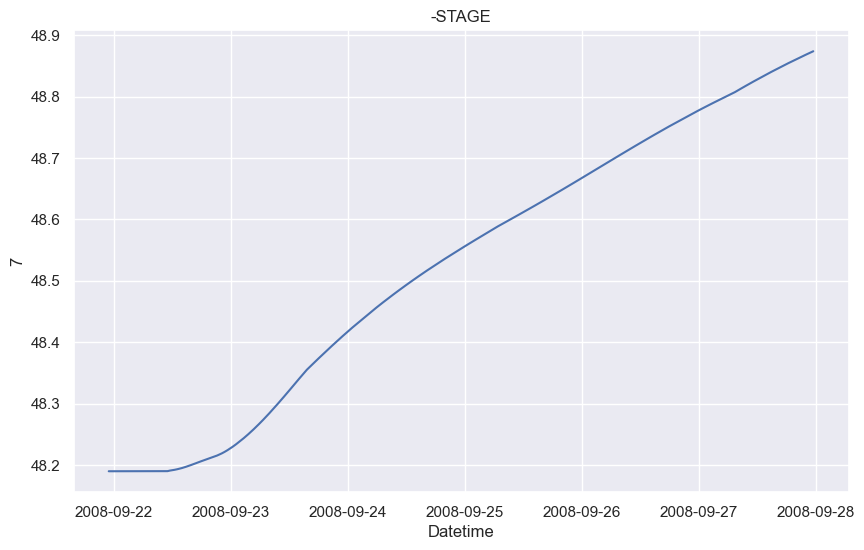

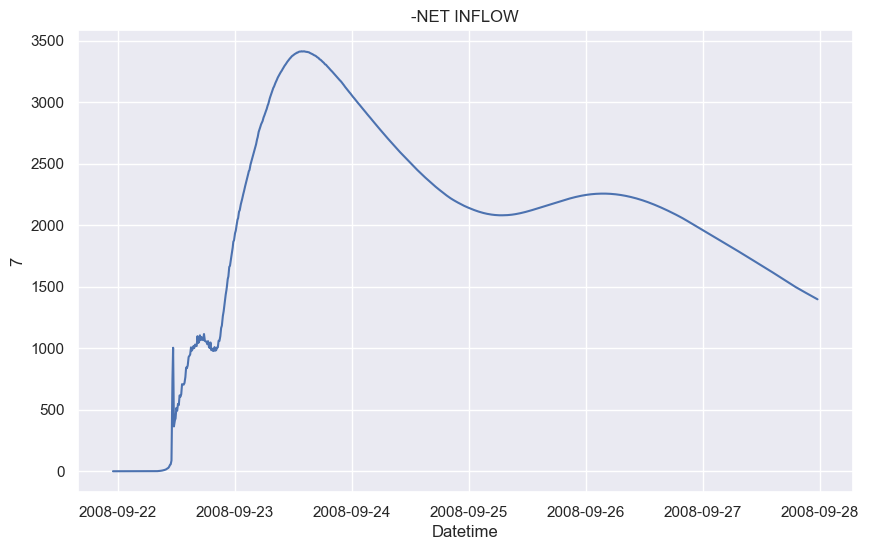

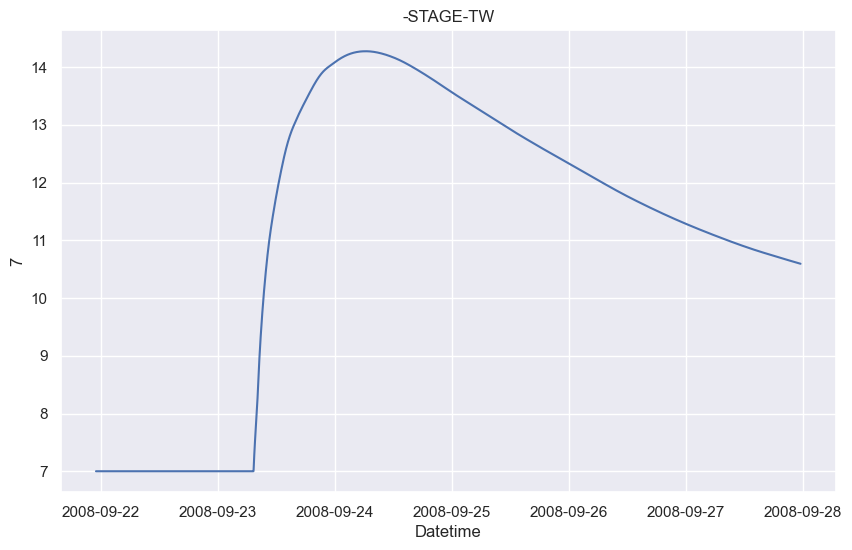

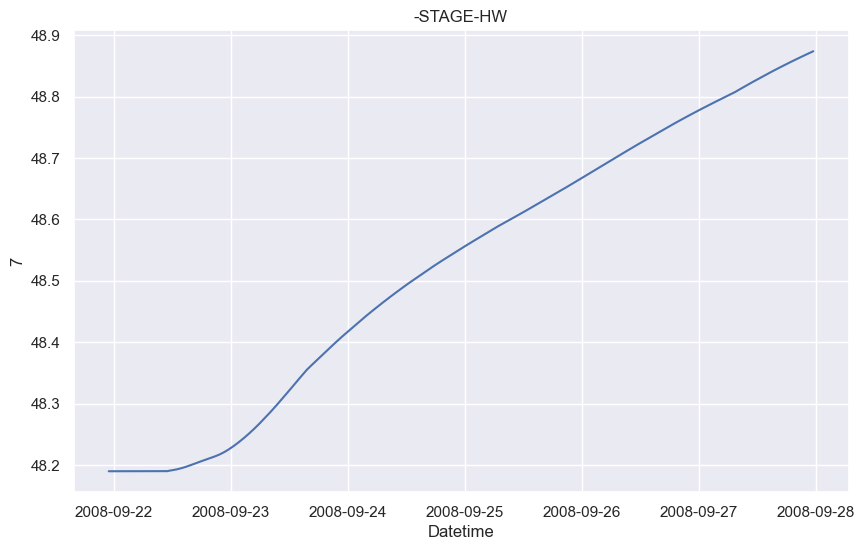

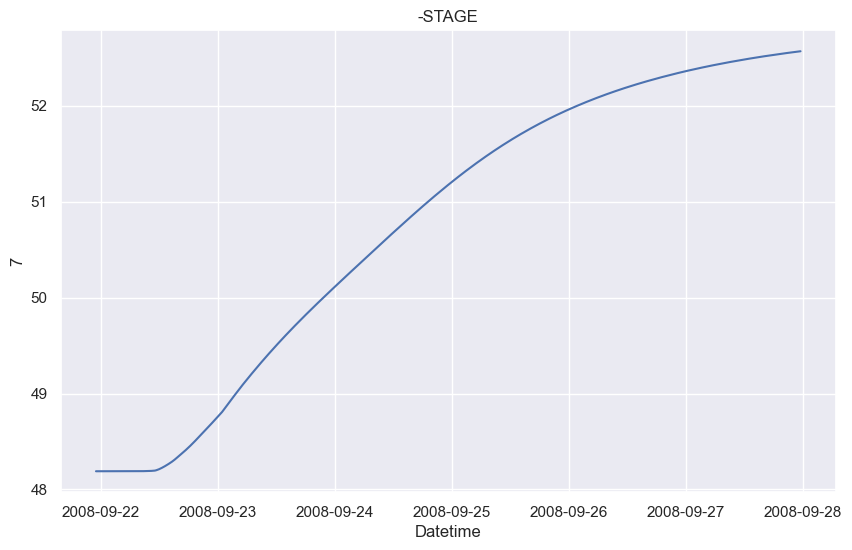

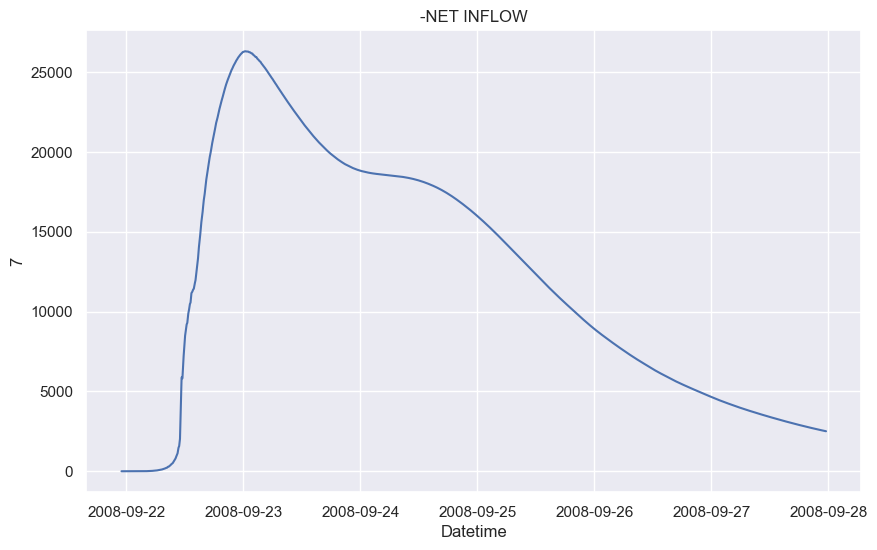

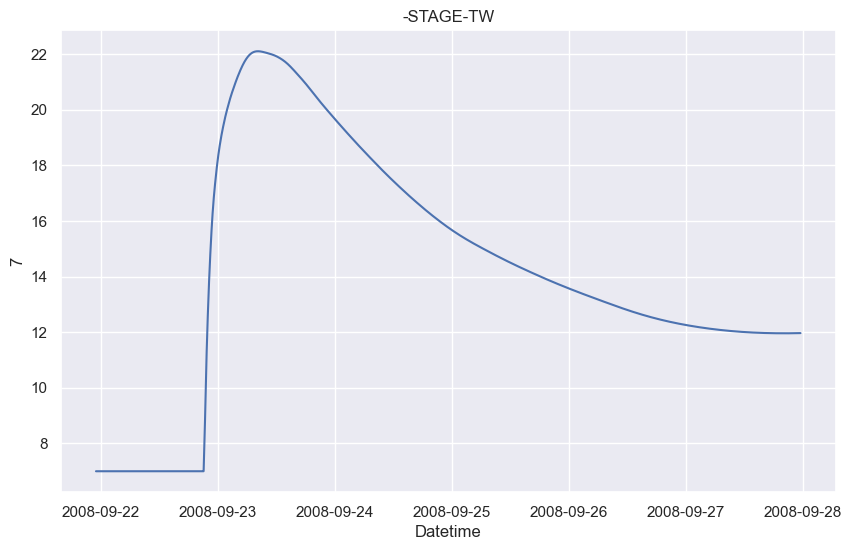

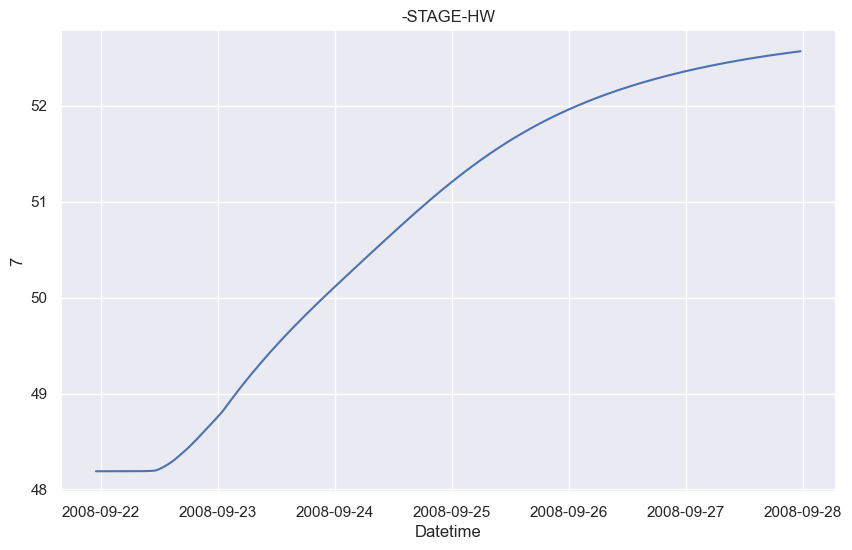

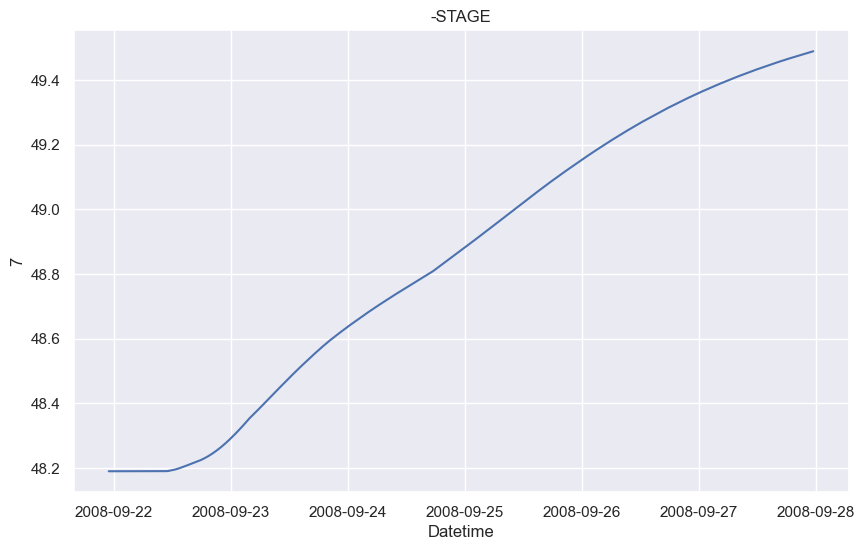

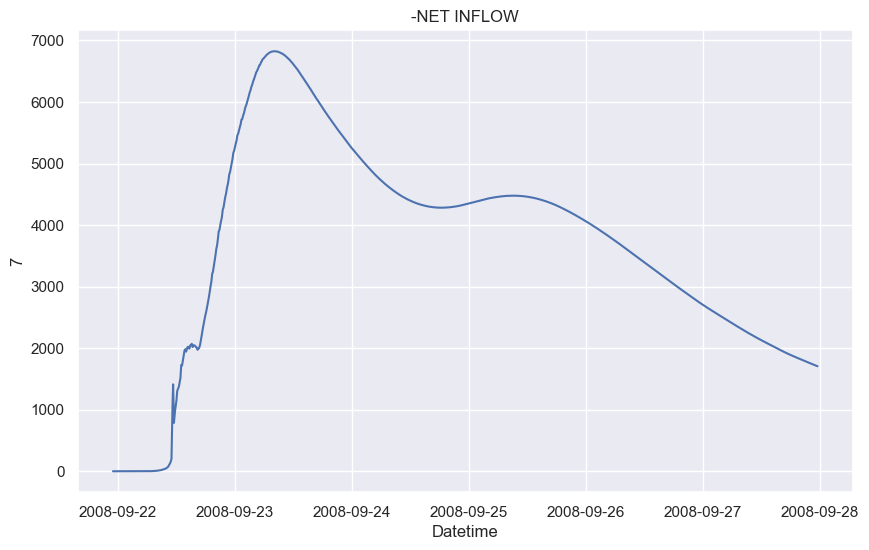

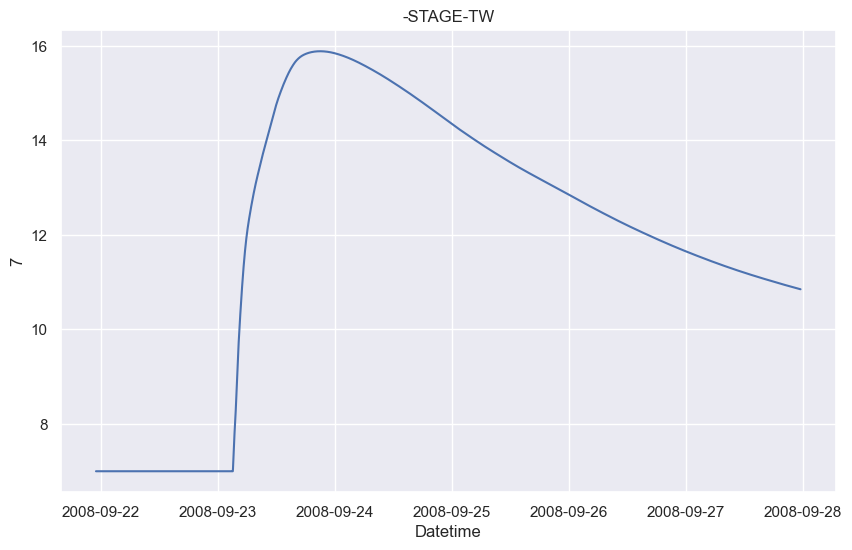

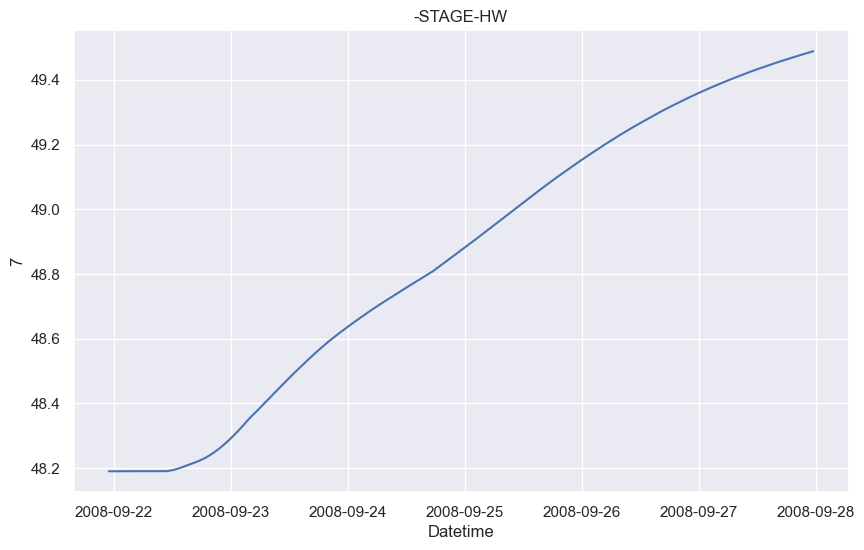

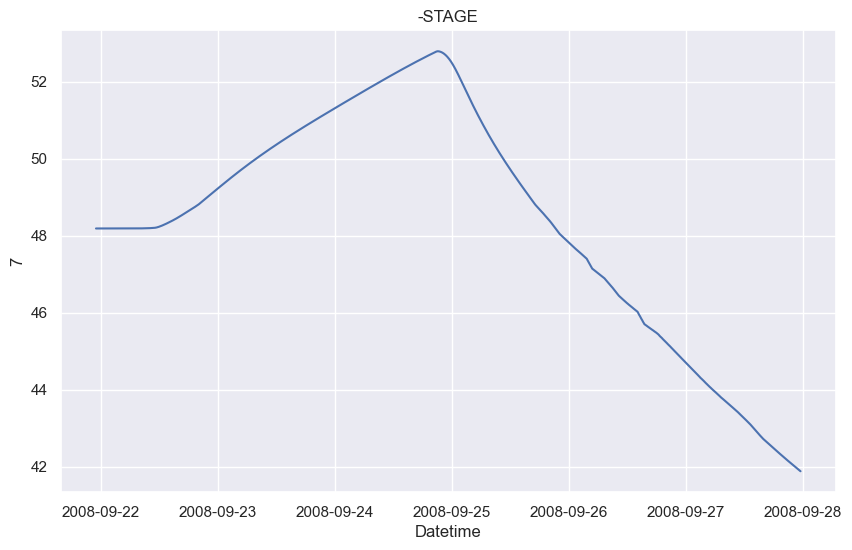

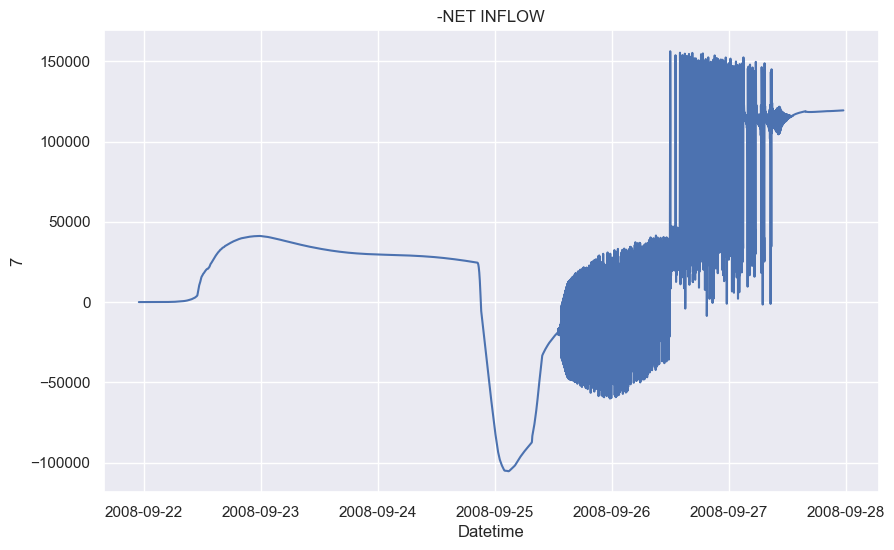

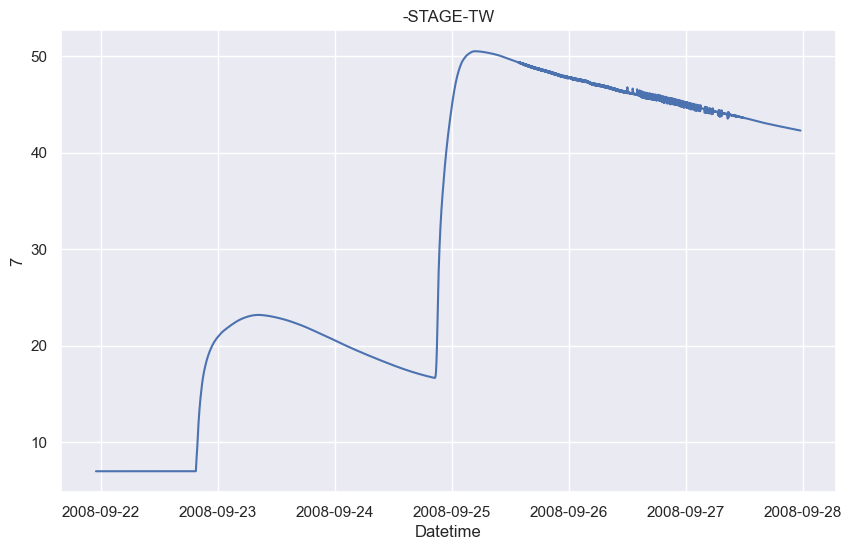

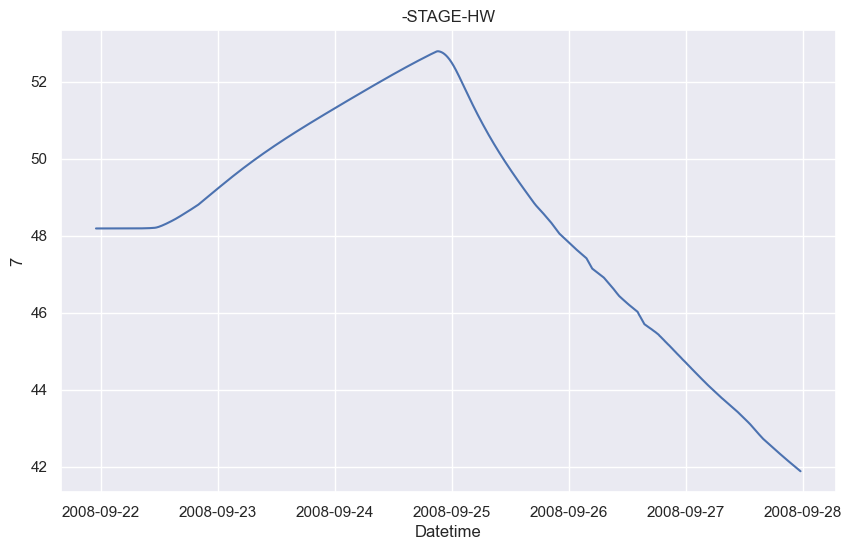

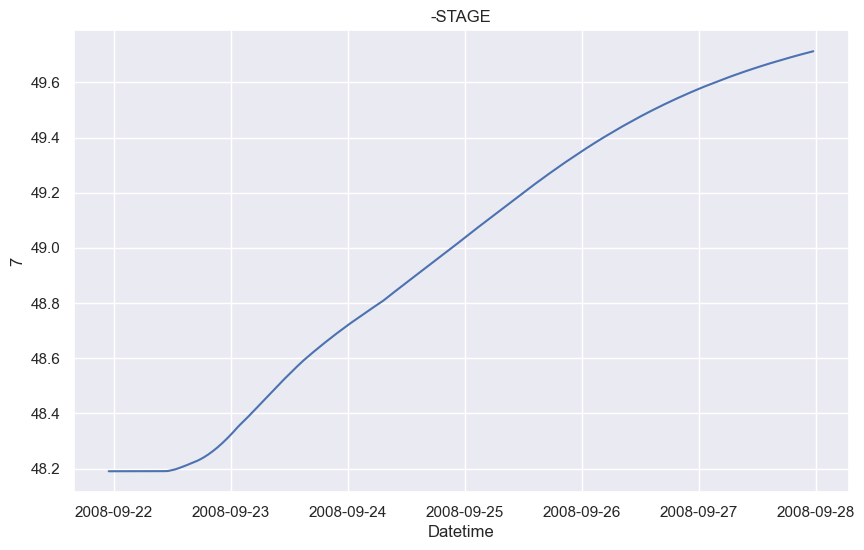

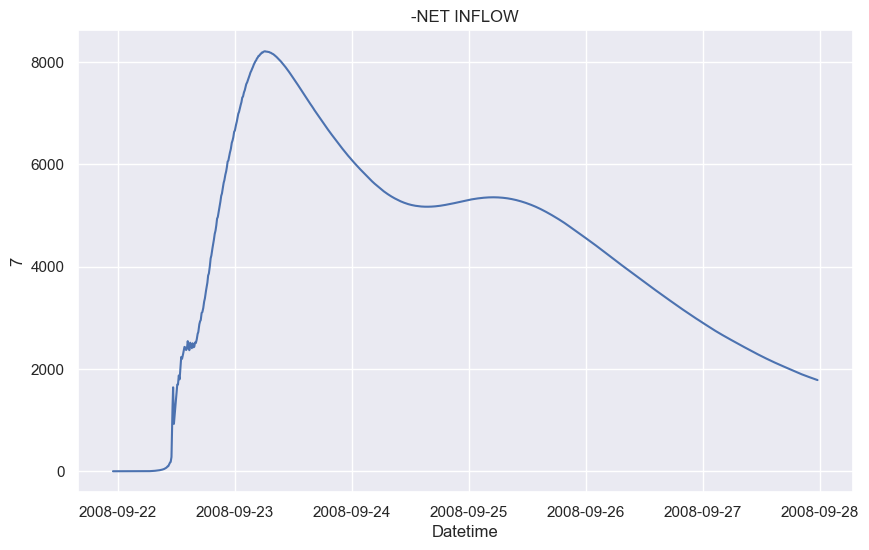

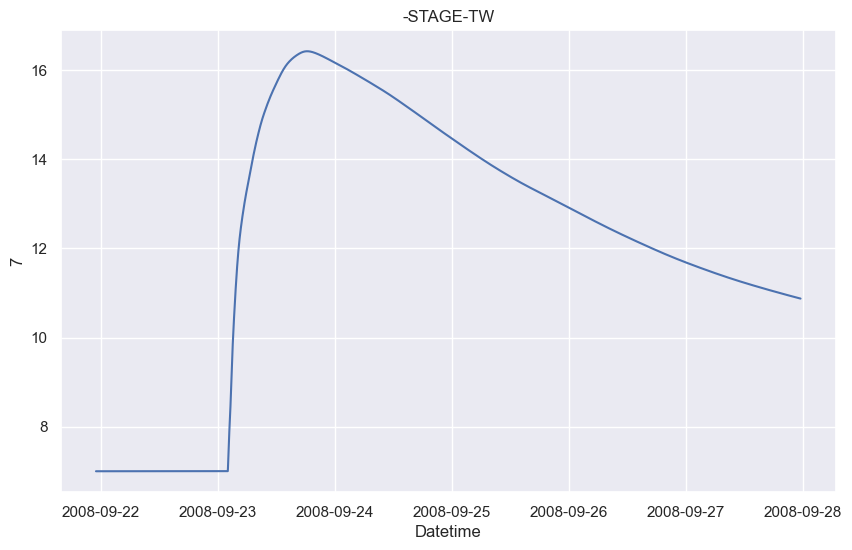

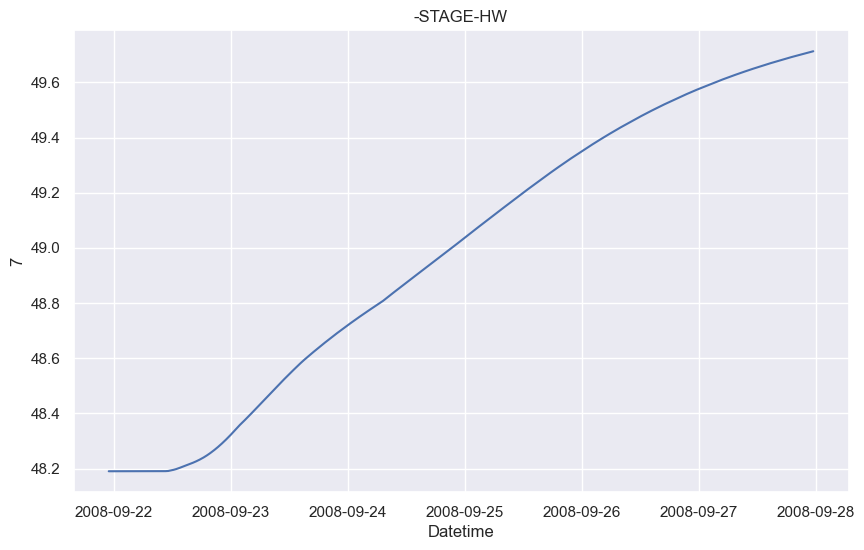

In [18]:
# Nombre de las BC-lines
BClines = ['Flow_up', 'aguas abajo (1)', 'aguas abajo (13)', 'aguas abajo (15)', 'aguas abajo (17)', 'aguas abajo (19)', 'aguas abajo (2)', 'aguas abajo (20)',  
           'aguas abajo (3)', 'aguas abajo (4)', 'aguas abajo (5)', 'aguas abajo (6)', 'aguas abajo (8)', 'aguas abajo (9)', 'BC Line 1']

# definir rutas
plan = 'Plan 02'
path_project = 'E:/SURINAM/03_MODELADO/02_HEC_RAS/Down_V4CC/'
name_project = 'Surinam'
path_save_   = 'Output/dam_break/'
ruta_origen  = 'E:/SURINAM/03_MODELADO/02_HEC_RAS/Down_V4CC/Plan 02/'
version_hecras = 641

# Obtén la lista de nombres de carpetas donde estas los hidrogramas almacenados
directorio = 'Output/Flow/Down_Salva_smoth/'
# return_period = [nombre for nombre in os.listdir(directorio) if os.path.isdir(os.path.join(directorio, nombre))]
#return_period = sorted(return_period, key=lambda x: int(''.join(filter(str.isdigit, x))))

# Recorrer Tr
for tr in return_period:
    print(tr)
    # Leer fichero .u
    with open(path_project+'Surinam.u01', "r") as archivo:
        lines = archivo.readlines()
    
    # 1. Actualizar fichero .u con hidrogramas almacenados en .csv
    # .................................................................................................................
    for ii, bc_line in tqdm.tqdm(enumerate(BClines)):
        # Read flows upstream
        if  bc_line =='Flow_up':
            nuevas_lineas = pd.read_csv('Output/Flow/Up/' + tr + '.csv')
        else:
            # read flows downstream
            nuevas_lineas = pd.read_csv(directorio + tr + '/' + bc_line + '.csv')
        
        # 1.1. Convertir serie en formato HEC RAS
        string = create_series(nuevas_lineas)
        # a. Índices de las filas que deseas eliminar
        inicio = lineas_loc[bc_line][0]+2
        # b .agregar valores
        lines[inicio] = string

        # c .Filtrar la lista para mantener solo las líneas que están fuera del rango
        indice_inicio = lineas_loc[bc_line][0]+3
        indice_fin = lineas_loc[bc_line][0]+89
        lines = lines[:indice_inicio] + lines[indice_fin:]
        # d. Actualizar indices
        if ii < len(BClines)-1:
            indice = buscar_indice(BClines[ii+1], lines)
            lineas_loc[BClines[ii+1]] = [indice+1]
    
    # e. Guardar el archivo TXT modificado
    with open(path_project+'Surinam.u01', 'w') as file:
        file.writelines(lines)
           
    # 2. Run Hec RAS        
    # .................................................................................................................
    rc = rascontrol.RasController(version=str(version_hecras))
    rc.open_project(path_project+name_project+'.prj')# ABRIR PROYECTO
    rc.run_current_plan()
    rc.close()
    
    # 3. Save results
    # .................................................................................................................
    os.makedirs(path_save_ + tr, exist_ok=True) # crear carpeta
    # a. Create .csv results
    for i in lista:
        # Dividir la cadena por '/'
        nombre_bcline = i.split('/')
        # Extraer la parte entre el primer y segundo '/'
        path_dss = plan+'/'+plan
        generate_flow_down(path_project, path_dss, path_save_ + tr + '/', nombre_bcline[2][17:] + '-' + nombre_bcline[3], i)
        print(nombre_bcline[2][17:] + '-' + nombre_bcline[3])
        
    # copiar y pegar mapas
    copyfile(ruta_origen +'D _ V (Max).Up_down.Up_down (2).up_down_4_clip.tif', path_save_ + tr + '/'+ 'D _ V (Max).Up_down.Up_down (2).up_down_4_clip.tif')
    copyfile(ruta_origen +'Depth (Max).Up_down.Up_down (2).up_down_4_clip.tif', path_save_ + tr + '/'+ 'Depth (Max).Up_down.Up_down (2).up_down_4_clip.tif')
    copyfile(ruta_origen +'Velocity (Max).Up_down.Up_down (2).up_down_4_clip.tif', path_save_ + tr + '/'+ 'Velocity (Max).Up_down.Up_down (2).up_down_4_clip.tif')
    
    # Copiar la carpeta de origen a la carpeta de destino
    shutil.copytree(path_project, path_save_ + tr + '/'+tr,)
    # os.remove(path_project, name_project, path_save_ + nombre_carpeta + '/Depth (Max).Terrain.Terrain_V5.MDT_V4_Final.tif')

## Results Upstream

### Sistema internacional

In [91]:
Path_up = 'Output/Flow/Up/'

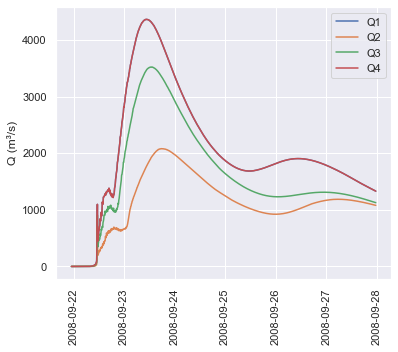

In [92]:
Tr = '10000'
Qup_10000_I1 = pd.read_csv(Path_up+Tr+'_'+'I4'+'.csv', index_col = 0, parse_dates = True)
Qup_10000_I2 = pd.read_csv(Path_up+Tr+'_'+'I2'+'.csv', index_col = 0, parse_dates = True)
Qup_10000_I3 = pd.read_csv(Path_up+Tr+'_'+'I3'+'.csv', index_col = 0, parse_dates = True)
Qup_10000_I4 = pd.read_csv(Path_up+Tr+'_'+'I4'+'.csv', index_col = 0, parse_dates = True)

plt.figure(figsize = (6, 5))
plt.plot(Qup_10000_I1['7'], label = 'Q1')
plt.plot(Qup_10000_I2['7'], label = 'Q2')
plt.plot(Qup_10000_I3['7'], label = 'Q3')
plt.plot(Qup_10000_I4['7'], label = 'Q4')
plt.ylabel('Q (m³/s)')
# Rotar los labels del eje x
plt.xticks(rotation=90)
plt.legend();

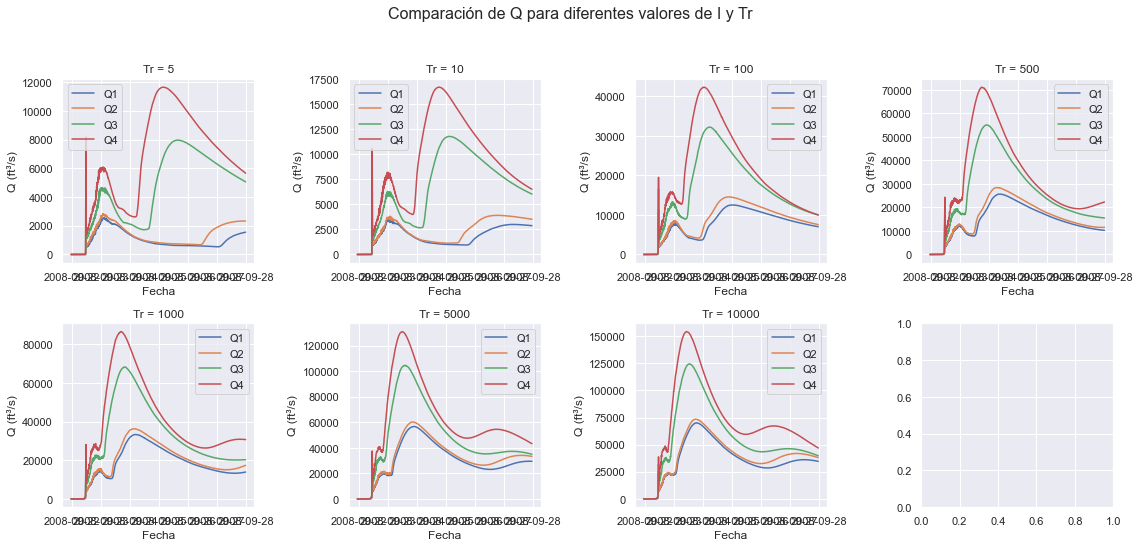

In [93]:
# Lista de valores de Tr
valores_Tr = [5, 10, 100, 500, 1000, 5000, 10000]

# Factor de conversión de m³/s a ft³/s (ajusta según tus necesidades)
conversion_factor = 35.3147

# Crear subgráficos
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Comparación de Q para diferentes valores de I y Tr', fontsize=16)

# Iterar sobre diferentes valores de Tr
for i, Tr in enumerate(valores_Tr):
    # Leer los archivos CSV
    Qup_I1 = pd.read_csv(Path_up + f'{Tr}_I1.csv', index_col=0, parse_dates=True)
    Qup_I2 = pd.read_csv(Path_up + f'{Tr}_I2.csv', index_col=0, parse_dates=True)
    Qup_I3 = pd.read_csv(Path_up + f'{Tr}_I3.csv', index_col=0, parse_dates=True)
    Qup_I4 = pd.read_csv(Path_up + f'{Tr}_I4.csv', index_col=0, parse_dates=True)

    # Obtener el índice de fila y columna para el subgráfico actual
    row = i // 4
    col = i % 4

    # Subgráfico actual
    ax = axs[row, col]

    # Plotear los datos
    ax.plot(Qup_I1['7'] * conversion_factor, label='Q1')
    ax.plot(Qup_I2['7'] * conversion_factor, label='Q2')
    ax.plot(Qup_I3['7'] * conversion_factor, label='Q3')
    ax.plot(Qup_I4['7'] * conversion_factor, label='Q4')

    # Configuración del subgráfico
    ax.set_title(f'Tr = {Tr}')
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Q (ft³/s)')
    ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Ajustar el espacio entre los subgráficos y el título principal
plt.show()

### Sitema ingles

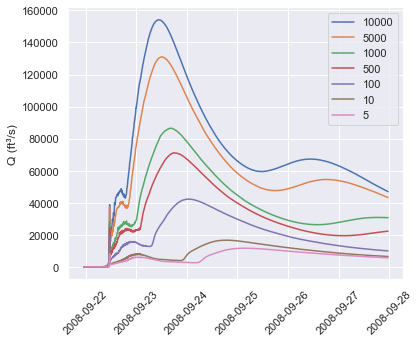

In [94]:
I = 'I4'

# Lista de etiquetas y archivos CSV
etiquetas = ['10000', '5000', '1000', '500', '100', '10', '5']
archivos = [f'{cantidad}_{I}.csv' for cantidad in etiquetas]

# Diccionario para almacenar los DataFrames
datos = {}

# Leer los archivos CSV y almacenar en el diccionario
for etiqueta, archivo in zip(etiquetas, archivos):
    datos[etiqueta] = pd.read_csv(Path_up + archivo, index_col=0, parse_dates=True)

# Factor de conversión de m³/s a ft³/s (ajusta según tus necesidades)
conversion_factor = 35.3147

# Crear el gráfico
plt.figure(figsize=(6, 5))

# Iterar sobre el diccionario, convertir y plotear cada conjunto de datos
for etiqueta, df in datos.items():
    # Convertir la columna '7' de m³/s a ft³/s
    df['7'] = df['7'] * conversion_factor
    
    # Plotear los datos convertidos
    plt.plot(df['7'], label=etiqueta)

# Rotar los labels del eje x
plt.xticks(rotation=45)  # Ajusta el ángulo de rotación según tus necesidades

plt.ylabel('Q (ft³/s)')  # Actualiza la etiqueta del eje y
plt.legend()
plt.show()

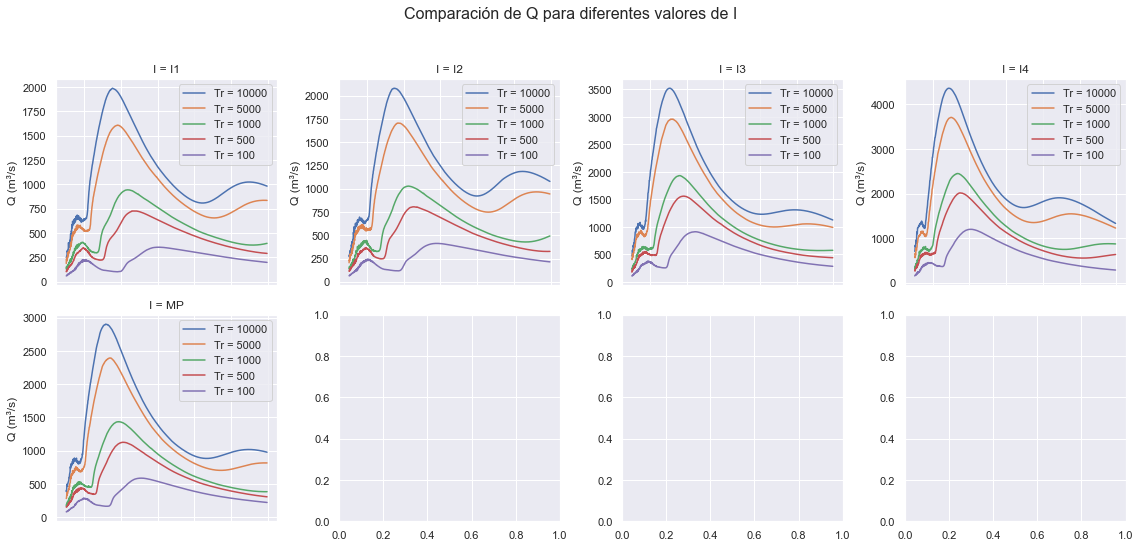

In [140]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

# Lista de etiquetas y archivos CSV
etiquetas = ['10000', '5000', '1000', '500', '100', '10', '5']

# Factor de conversión de m³/s a ft³/s (ajusta según tus necesidades)
conversion_factor = 1#35.3147

# Crear subgráficos
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Comparación de Q para diferentes valores de I', fontsize=16)

# Iterar sobre diferentes valores de I
for i, I in enumerate(['I1', 'I2', 'I3', 'I4', 'MP']):
    # Diccionario para almacenar los DataFrames
    datos = {}

    # Leer los archivos CSV y almacenar en el diccionario
    for etiqueta in etiquetas:
        archivo = f'{etiqueta}_{I}.csv'
        datos[etiqueta] = pd.read_csv(Path_up + archivo, index_col=0, parse_dates=True)

    # Obtener el índice de fila y columna para el subgráfico actual
    row = i // 4
    col = i % 4

    # Subgráfico actual
    ax = axs[row, col]

    # Iterar sobre el diccionario, convertir y plotear cada conjunto de datos
    for etiqueta, df in list(datos.items())[:-2]:
        # Convertir la columna '7' de m³/s a ft³/s
        df['7'] = df.iloc[80:,:]['7'] * conversion_factor

        # Plotear los datos convertidos
        ax.plot(df['7'], label=f'Tr = {etiqueta}')

    # Rotar los labels del eje x
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

    # Configuración del subgráfico
    ax.set_title(f'I = {I}')
    ax.set_ylabel('Q (m³/s)')
    ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Ajustar el espacio entre los subgráficos y el título principal
plt.show()

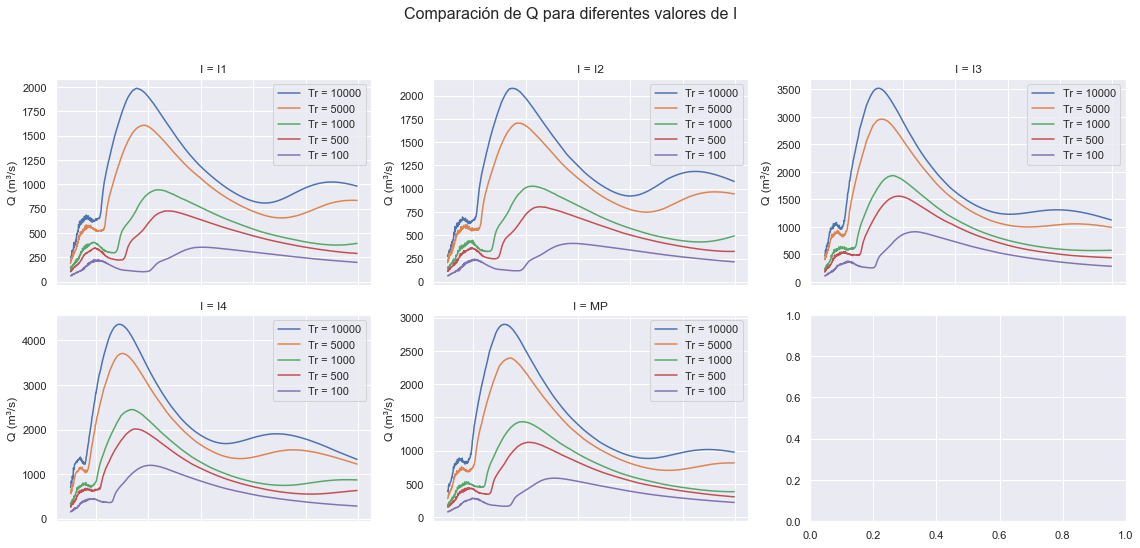

In [142]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

# Lista de etiquetas y archivos CSV
etiquetas = ['10000', '5000', '1000', '500', '100', '10', '5']

# Factor de conversión de m³/s a ft³/s (ajusta según tus necesidades)
conversion_factor = 1#35.3147

# Crear subgráficos
fig, axs = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Comparación de Q para diferentes valores de I', fontsize=16)

# Iterar sobre diferentes valores de I
for i, I in enumerate(['I1', 'I2', 'I3', 'I4', 'MP']):
    # Diccionario para almacenar los DataFrames
    datos = {}

    # Leer los archivos CSV y almacenar en el diccionario
    for etiqueta in etiquetas:
        archivo = f'{etiqueta}_{I}.csv'
        datos[etiqueta] = pd.read_csv(Path_up + archivo, index_col=0, parse_dates=True)

    # Obtener el índice de fila y columna para el subgráfico actual
    row = i // 3
    col = i % 3

    # Subgráfico actual
    ax = axs[row, col]

    # Iterar sobre el diccionario, convertir y plotear cada conjunto de datos
    for etiqueta, df in list(datos.items())[:-2]:
        # Convertir la columna '7' de m³/s a ft³/s
        df['7'] = df.iloc[80:,:]['7'] * conversion_factor

        # Plotear los datos convertidos
        ax.plot(df['7'], label=f'Tr = {etiqueta}')

    # Rotar los labels del eje x
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

    # Configuración del subgráfico
    ax.set_title(f'I = {I}')
    ax.set_ylabel('Q (m³/s)')
    ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Ajustar el espacio entre los subgráficos y el título principal
plt.show()

## Downstream results

En este apartado se suavizaran los hidrogramas, asociados a los resultados de la modelación aguas abajo de la presa

In [14]:
Path_salva = "Y:/03_MODELADO/6_Notebooks/Output/Flow/Down/"
Path_salva_smoth = 'E:/SURINAM/6_Notebooks/Output/Flow/Down_salva_smoth/'

In [7]:
nombres_ficheros = os.listdir(Path_salva+'10000_I1')

# Números y prefijos que deseas mantener
numeros_a_mantener = {8, 3, 6, 15, 4, 1, 2, 19, 20, 17, 13, 5, 9}
prefijos_a_eliminar = {'Reference Line'}

# Filtrar la lista original
nombres_ficheros_filtrados = [archivo for archivo in nombres_ficheros if not any(prefijo in archivo for prefijo in prefijos_a_eliminar) and any(numero in archivo for numero in map(str, numeros_a_mantener))]

FileNotFoundError: [WinError 3] El sistema no puede encontrar la ruta especificada: 'Y:/03_MODELADO/6_Notebooks/Output/Flow/Down/10000_I1'

In [17]:
nombres_carpetas = os.listdir(Path_salva)
nombres_carpetas_filtrada = os.listdir(Path_salva) #[elemento for elemento in nombres_carpetas if "CC" not in elemento]
nombres_carpetas_filtrada

['10000_CC_mas',
 '10000_CC_menos',
 '10000_I1',
 '10000_I2',
 '10000_I3',
 '10000_I4',
 '10000_Mp',
 '1000_CC_mas',
 '1000_CC_menos',
 '1000_I1',
 '1000_I2',
 '1000_I3',
 '1000_I4',
 '1000_Mp',
 '100_CC_mas',
 '100_CC_menos',
 '100_I1',
 '100_I2',
 '100_I3',
 '100_I4',
 '100_Mp',
 '10_CC_mas',
 '10_CC_menos',
 '10_I1',
 '10_I2',
 '10_I3',
 '10_I4',
 '10_Mp',
 '5000_I1',
 '5000_I2',
 '5000_I3',
 '5000_I4',
 '5000_Mp',
 '500_I1',
 '500_I2',
 '500_I3',
 '500_I4',
 '500_Mp',
 '5_I1',
 '5_I2',
 '5_I3',
 '5_I4',
 '5_Mp']

In [20]:
nombres_carpetas_filtrada[28:30]

['5000_I1', '5000_I2']

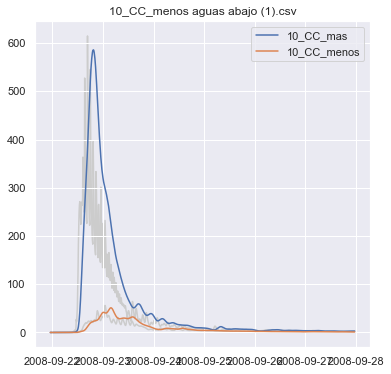

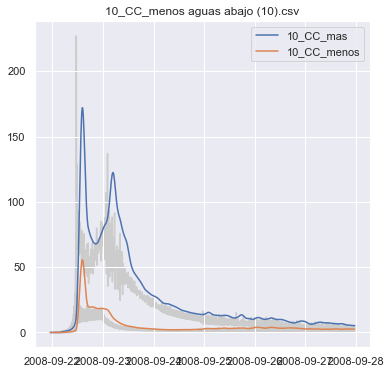

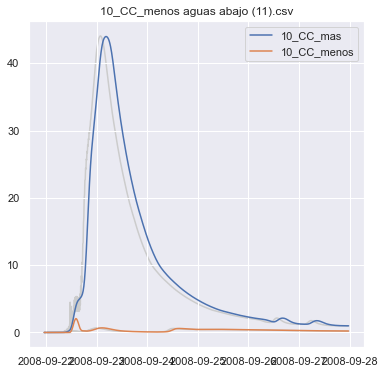

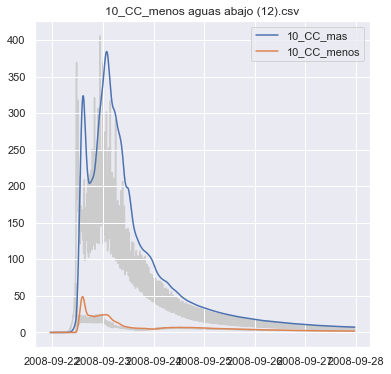

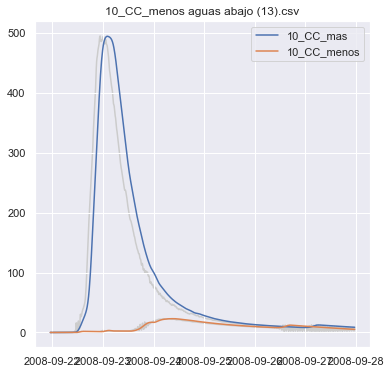

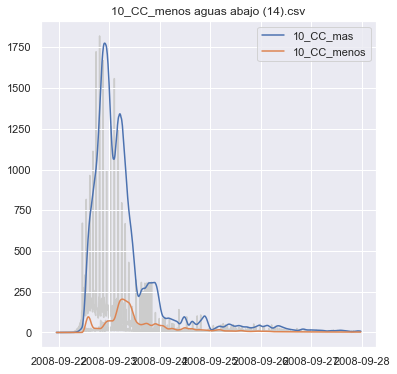

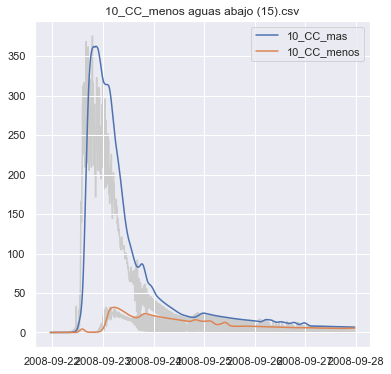

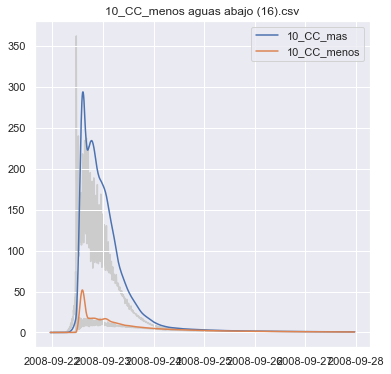

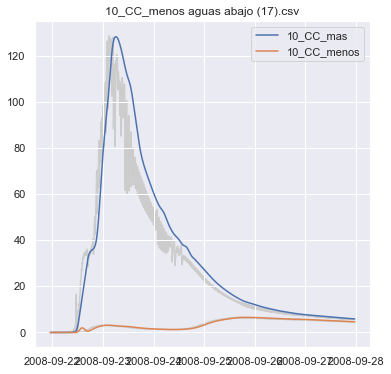

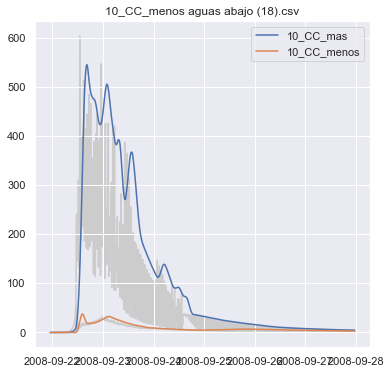

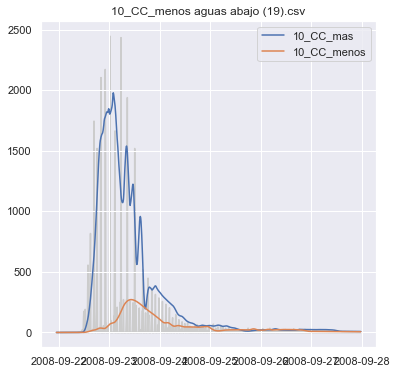

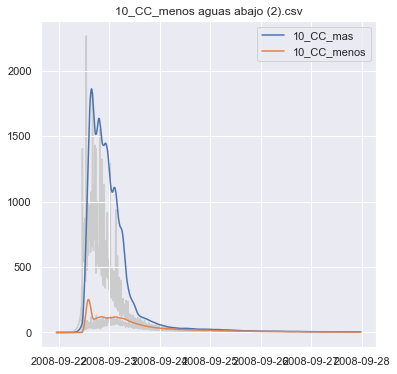

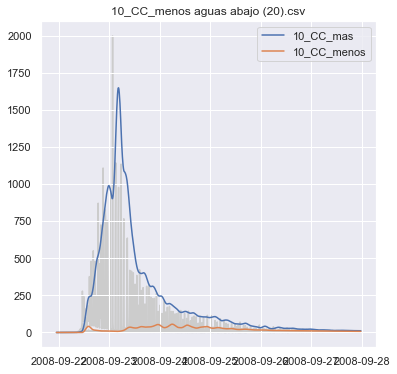

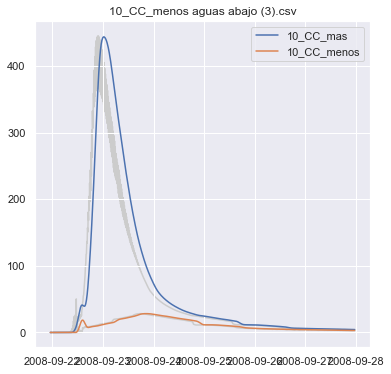

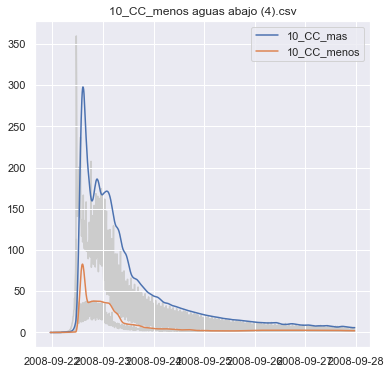

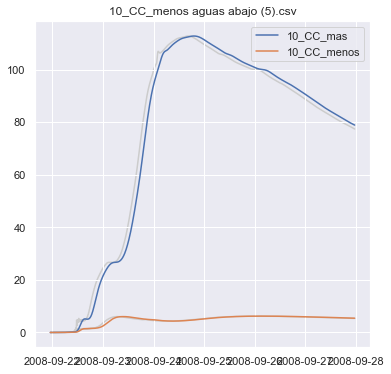

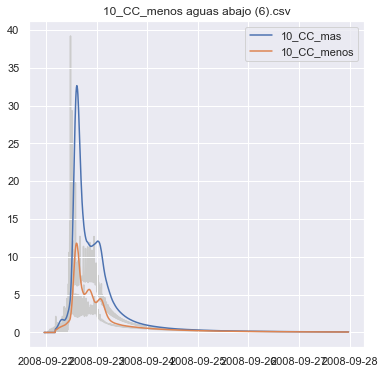

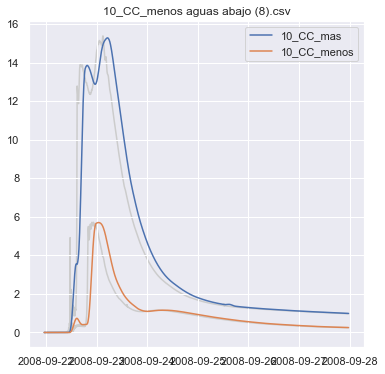

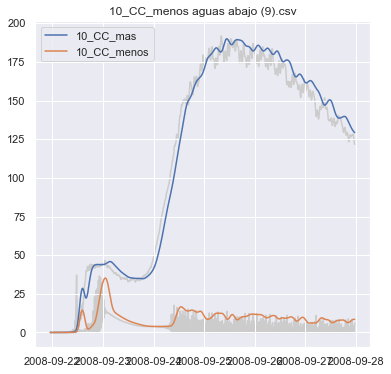

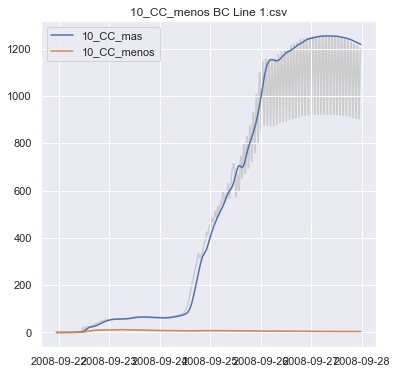

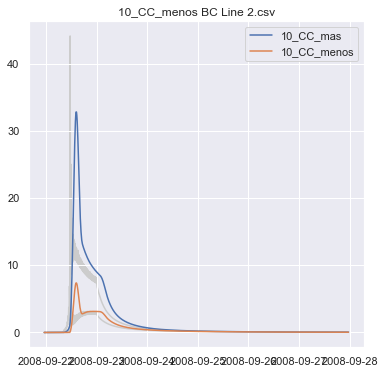

In [80]:
nombres_carpetas = os.listdir(Path_salva)

for nombre in nombres_ficheros_filtrados:
    fig, ax = plt.subplots(1, 1, figsize = (6, 6))
    for folder in nombres_carpetas_filtrada[21:23]:# cambiar a nombre carpetas para incluir CC cuando se tengan los datos 

        # read data
        datos = pd.read_csv(Path_salva+folder+'/'+nombre, index_col = 0, parse_dates = True)
        
        # suavisar series
        # .............................................................
        l = ['aguas abajo (14)', 'aguas abajo (15)', 'aguas abajo (18)', 'aguas abajo (2)']
        if nombre in l:
            df_max = suavizar_serie_temporal_maximo(datos, '7', ventana=10)
            df_max1 = suavizar_serie_temporal(df_max, '7', ventana=20)
            df_max1 = suavizar_serie_temporal(df_max1, '7', ventana=25)
        else:
            df_max = suavizar_serie_temporal_maximo(datos, '7', ventana=10)
            df_max1 = suavizar_serie_temporal(df_max, '7', ventana=10)
            df_max1 = suavizar_serie_temporal(df_max1, '7', ventana=15)
            # rellenar con cero datos nulos
        df_max1['7'] = df_max1['7'].fillna(0)
        # Graficar datos
        # ............................................................
        ax.plot(datos, color = '0.8', zorder = 0)
        ax.plot(df_max1, label = folder)
        ax.set_title(folder+' '+nombre)
        ax.legend();
        
        # Guardar series ajustadas
        # ........................................................
        # Crear folder 
        crear_nueva_carpeta(Path_salva_smoth, folder)
        df_max1.to_csv(Path_salva_smoth + folder + '/' + nombre)

In [4]:
# Ruta de la carpeta
carpeta_path = r'E:\SURINAM\6_Notebooks\Output\dam_break\open_gates'

# Obtener la lista de nombres de carpetas
nombres_carpetas = [nombre for nombre in os.listdir(carpeta_path) if os.path.isdir(os.path.join(carpeta_path, nombre))]
nombres_carpetas

['10000_CC_1',
 '10000_CC_2',
 '10000_I1',
 '10000_I2',
 '10000_I3',
 '10000_I4',
 '100_I4',
 '100_Mp',
 '10_CC_1',
 '10_CC_2',
 '10_I1',
 '10_I2',
 '10_I3',
 '10_I4',
 '10_Mp',
 '5000_I1',
 '5000_I2',
 '5000_I3',
 '5000_I4',
 '5000_Mp',
 '5_I1',
 '5_I2',
 '5_I3',
 '5_I4',
 '5_Mp']

In [5]:
import os

In [26]:
nombres_carpetas

['10000_CC_1',
 '10000_CC_2',
 '10000_I1',
 '10000_I2',
 '10000_I3',
 '10000_I4',
 '1000_CC_mas',
 '1000_CC_menos',
 '1000_I1',
 '1000_I2',
 '1000_I3',
 '1000_I4',
 '100_I4',
 '100_Mp',
 '10_CC_1',
 '10_CC_2',
 '10_I1',
 '10_I2',
 '10_I3',
 '10_I4',
 '10_Mp',
 '5000_I1',
 '5000_I2',
 '5000_I3',
 '5000_I4',
 '5000_Mp',
 '500_I1',
 '500_I2',
 '500_I3',
 '500_I4',
 '500_Mp',
 '5_I1',
 '5_I2',
 '5_I3',
 '5_I4',
 '5_Mp']

In [28]:
nombres_carpetas = [nombre for nombre in os.listdir(carpeta_path) if os.path.isdir(os.path.join(carpeta_path, nombre))]
nombres_carpetas[6:12]

['1000_CC_mas', '1000_CC_menos', '1000_I1', '1000_I2', '1000_I3', '1000_I4']

In [29]:
import os
import shutil

carpeta_path = r'E:\SURINAM\6_Notebooks\Output\dam_break\open_gates'

# Obtener la lista de nombres de carpetas
nombres_carpetas = [nombre for nombre in os.listdir(carpeta_path) if os.path.isdir(os.path.join(carpeta_path, nombre))]

# Iterar sobre cada carpeta
for carpeta in nombres_carpetas[6:12]:
    carpeta_path_completa = os.path.join(carpeta_path, carpeta)

    # Obtener la lista de archivos en la carpeta
    archivos_en_carpeta = os.listdir(carpeta_path_completa)

    # Filtrar solo los archivos que contienen los nombres especificados
    archivos_a_copiar = [archivo for archivo in archivos_en_carpeta if 'D _ V (Max)' in archivo or 'Depth (Max)' in archivo or 'Velocity (Max)' in archivo]

    # Crear copias de los archivos con los nuevos nombres
    for archivo in archivos_a_copiar:
        if 'Velocity' in archivo:
            nuevo_prefijo = 'Velocity'
        elif 'Depth' in archivo:
            nuevo_prefijo = 'Depth'
        else:
            nuevo_prefijo = 'D_V'

        nuevo_nombre = f'{nuevo_prefijo}_RP{carpeta}_OG.tif'
        vieja_ruta = os.path.join(carpeta_path_completa, archivo)
        nueva_ruta = os.path.join(carpeta_path_completa, nuevo_nombre)
        shutil.copy2(vieja_ruta, nueva_ruta)

print("Copias de archivos creadas con éxito.")

Copias de archivos creadas con éxito.


In [12]:
carpeta_path_completa

'E:\\SURINAM\\6_Notebooks\\Output\\dam_break\\open_gates\\10_CC_2'

In [ ]:
rc = rascontrol.RasController(version=str(version_hecras))
rc.open_project(path_project+name_river+'.prj')# ABRIR PROYECTO
rc.run_current_plan()
rc.close()

copyfile(path_project+name_output+'/Depth (Max).Terrain.Terrain_V5.MDT_V4_Final.tif', path_image_output+name_image)
os.remove(path_project+name_output+'/Depth (Max).Terrain.Terrain_V5.MDT_V4_Final.tif')

In [2]:
def Execute_Hec_RAS(config):
    path_project      = config['path_project']
    name_river        = config['name_river']
    flow_title        = config['flow_title']
    path_eventos      = config['path_eventos']
    version_hecras    = config['version_hecras']
    number_sim_flow   = config['number_sim_flow']
    number_sim_plan   = config['number_sim_plan']
    steady_flow       = config['steady_flow']
    name_output       = config['name_output']
    path_image_output = config['path_image_output']
    name_image        = config['name_image']
    
    # leler la u5 de referencia
    with open(path_project+name_river+'.u'+'{:02d}'.format(number_sim_flow), "r") as out_file:
        lines = out_file.readlines()
        out_file.close()

#     for l, ll in enumerate(lines):
#         if 'Flow Hydrograph=' in ll:
#             pos_fh = l
#             number_steps = int(ll.split(' ')[2])
#             n_lines = math.ceil(number_steps/10)

#     hidrograma = pd.read_csv(path_eventos,index_col=0)

#     x = hidrograma.index/3600
#     y = hidrograma.values.reshape(1,-1)

#     f1 = interp1d(x, y, kind='linear')

#     x1 = np.arange(0,int(np.max(x)))

#     Flow = f1(x1)[0]

#     lines_new = list()
#     for i in range(0,len(Flow),10):
#         line_data = Flow[i:i+10]
#         for j, jj in enumerate(line_data):
#             if i==0 and j==0:
#                 string = '{:8.2f}'.format(jj)
#             else:
#                 if j ==9:
#                     string = string + '{:8.2f}'.format(jj)+'\n'
#                 else:
#                     string = string + '{:8.2f}'.format(jj)

#     if (len(Flow)/10).is_integer()==False:
#         string = string +'\n'

#     final_lines = ['Flow Title='+flow_title+'\n']+lines[1:pos_fh]+['Flow Hydrograph= '+str(len(Flow))+'\n']+[string]+lines[pos_fh+1+n_lines:]

    with open(path_project+name_river+'.u'+'{:02d}'.format(99), "w") as fh:
        for line in final_lines:
            fh.write(line)
            
    with open(path_project+name_river+'.p'+'{:02d}'.format(number_sim_plan), "r") as out_file:
        lines = out_file.readlines()
        out_file.close()# number_sim_plan USAR EL MISMO TIEMPO DEL PLAN (A MANOPLA REVISAR)

#     for l, ll in enumerate(lines):
#         if 'Plan Title=' in ll:
#             pos_pt = l
#         elif 'Short Identifier=' in ll:
#             pos_pi = l
#         elif 'Flow File=' in ll:
#             pos_ff = l
#         elif 'Simulation Date=' in ll:
#             pos_date = l

#     dateTimeObj = datetime.now()-timedelta(days=1)
#     dateTimeObj2 = datetime.strptime(dateTimeObj.strftime('%d%b%Y')+','+str(23)+'00', '%d%b%Y,%H%M%S')
#     dateTime_final= dateTimeObj2+timedelta(hours=(len(Flow)))

#     if dateTime_final.hour==0:
#         dateTime_final = dateTime_final-timedelta(hours=1)


#     time = ['Simulation Date='+dateTimeObj.strftime('%d%b%Y').upper()+','+str(24)+'00'+','+dateTime_final.strftime('%d%b%Y').upper()+','+str(dateTime_final.hour)+'00'+'\n']


#     final_lines = ['Plan Title='+name_output+'\n']+[lines[pos_pt+1]]+['Short Identifier='+name_output+'\n']+time+\
#     lines[pos_pi+2:pos_pi+3]+['Flow File=u'+'{:02d}'.format(99)+'\n']+lines[pos_ff+1:]

#     with open(path_project+name_river+'.p'+'{:02d}'.format(99), "w") as fh:
#         for line in final_lines:
#             fh.write(line)

    # with open(path_project+name_river+'.prj', "r") as out_file:
    #     lines = out_file.readlines()
#     #     out_file.close()

#     pos_nf = False 

#     for l, ll in enumerate(lines):
#         if 'Unsteady File=' in ll:
#             pos_ff = l
#         elif 'Plan File=' in ll:
#             pos_pf = l
#     if 'p99' in lines[pos_pf]:
#         pos_nf = True


#     if pos_nf==True:
#          final_lines = [lines[0]]+['Current Plan=p'+'{:02d}'.format(99)+'\n']+\
#     lines[2:pos_ff:]+['Unsteady File=u'+'{:02d}'.format(99)+'\n']+lines[pos_ff+1:pos_pf]+['Plan File=p'+'{:02d}'.format(99)+'\n']+lines[pos_pf+1:]

#     else:

#         final_lines = [lines[0]]+['Current Plan=p'+'{:02d}'.format(99)+'\n']+\
#     lines[2:pos_ff+1:]+['Unsteady File=u'+'{:02d}'.format(99)+'\n']+lines[pos_ff+1:pos_pf+1]+['Plan File=p'+'{:02d}'.format(99)+'\n']+lines[pos_pf+1:]

#     with open(path_project+name_river+'.prj', "w") as fh:
#         for line in final_lines:
#             fh.write(line)

    rc = rascontrol.RasController(version=str(version_hecras))
    rc.open_project(path_project+name_river+'.prj')# ABRIR PROYECTO
    rc.run_current_plan()
    rc.close()
    
    copyfile(path_project+name_output+'/Depth (Max).Terrain.Terrain_V5.MDT_V4_Final.tif', path_image_output+name_image)
    os.remove(path_project+name_output+'/Depth (Max).Terrain.Terrain_V5.MDT_V4_Final.tif')


In [8]:
version_hecras = 641
path_project = 'D:/SURINAM/HECRAS/'
name_river = 'Surinam'
path_project+name_river+'.u'+'{:02d}'.format(5)

'D:/SURINAM/HECRAS/Surinam.u05'

In [ ]:
with open(path_project+name_river+'.u'+'{:02d}'.format(99), "w") as fh:
    for line in final_lines:
        fh.write(line)

In [ ]:
rc = rascontrol.RasController(version=str(version_hecras))
rc.open_project(path_project+name_river+'.prj')# ABRIR PROYECTO
rc.run_current_plan()
rc.close()

copyfile(path_project+name_output+'/Depth (Max).Terrain.Terrain_V5.MDT_V4_Final.tif', path_image_output+name_image)
os.remove(path_project+name_output+'/Depth (Max).Terrain.Terrain_V5.MDT_V4_Final.tif')

In [ ]:
for j,T in enumerate([2,5,10,25,50,100,200,500]):
    with open("Inputs.yml") as f:
        list_doc = yaml.load(f, Loader=yaml.FullLoader)
    list_doc['path_eventos'] =  'F:/salvador/Los_corrales_Buelna/Copulas_Gausianas/Hidrogramas_recontruidos_26_7_2021/Met_Hab/Hidrograma_T'+str(T)+'.csv'
    list_doc['name_image'] =  'Simul_T'+str(T)+'.tif'
    list_doc['path_image_output'] =  'F:/salvador/Los_corrales_Buelna/Reconstruccion_Hist/Mett_Hab/'
    f.close()
    
    with open("Inputs.yml", "w") as f:
        yaml.dump(list_doc, f)

    with open('Inputs.yml') as fidin:
        config = yaml.load(fidin,Loader=yaml.FullLoader)

    path_image_output = config['path_image_output']
    name_image        = config['name_image']

    Execute_Hec_RAS(config)

In [16]:
for i in tqdm.tqdm(range(0,425)):
    with open("Inputs.yml") as f:
         list_doc = yaml.load(f, Loader=yaml.FullLoader)
    list_doc['path_eventos'] =  'F:/salvador/Los_corrales_Buelna/Reconstruccion_Eventos/Hidrograma_'+str(i)+'.csv'
    list_doc['name_image'] =  'Simul_'+str(i)+'.tif'
    f.close()
    with open("Inputs.yml", "w") as f:
        yaml.dump(list_doc, f)

    with open('Inputs.yml') as fidin:
        config = yaml.load(fidin,Loader=yaml.FullLoader)
        
    path_image_output = config['path_image_output']
    name_image        = config['name_image']
        
    if os.path.exists(path_image_output+name_image):
        continue
    else:
        try:
            Execute_Hec_RAS(config)
        except:
            print('No pudo realizarse la simulación '+str(i))
            continue

  0%|▏                                                                                 | 1/425 [00:01<08:53,  1.26s/it]

No pudo realizarse la simulación 0


  0%|▍                                                                                 | 2/425 [00:02<08:27,  1.20s/it]

No pudo realizarse la simulación 1


  1%|▌                                                                                 | 3/425 [00:03<08:28,  1.20s/it]

...

  3%|██▍                                                                              | 13/425 [00:07<01:50,  3.71it/s]

No pudo realizarse la simulación 12


  3%|██▍                                                                              | 13/425 [00:07<04:08,  1.66it/s]

No pudo realizarse la simulación 13

KeyboardInterrupt: 

# Cambio Climático

In [4]:
for rcp in ['rcp45','rcp85']:
    for per in [[2011,2040,'MP'],[2041,2070,'MP'],[2071,2100,'LP']]:
        if os.path.exists('E:/salvador/Los_corrales_Buelna//Cambio_Climatico/Manchas_Inundacion/'+rcp+'_'+str(per[0])+'_'+str(per[1])+'/')==False:
                os.makedirs('E:/salvador/Los_corrales_Buelna//Cambio_Climatico/Manchas_Inundacion/'+rcp+'_'+str(per[0])+'_'+str(per[1]))
        for i in tqdm.tqdm(range(0,25)):
            with open("Inputs.yml") as f:
                 list_doc = yaml.load(f, Loader=yaml.FullLoader)
            list_doc['path_eventos'] =  'E:/salvador/Los_corrales_Buelna/Cambio_Climatico/Reconstruccion_Eventos/'+rcp+'_'+str(per[0])+'_'+str(per[1])+'/'+'Hidrograma_'+str(i)+'.csv'
            list_doc['name_image'] =  'Simul_'+str(i)+'.tif'
            list_doc['path_image_output'] =  'E:/salvador/Los_corrales_Buelna/Cambio_Climatico/Manchas_Inundacion/'+rcp+'_'+str(per[0])+'_'+str(per[1])+'/'
            f.close()
            with open("Inputs.yml", "w") as f:
                yaml.dump(list_doc, f)

            with open('Inputs.yml') as fidin:
                config = yaml.load(fidin,Loader=yaml.FullLoader)

            path_image_output = config['path_image_output']
            name_image        = config['name_image']

            if os.path.exists(path_image_output+name_image):
                continue
            else:
                Execute_Hec_RAS(config)

100%|█████████████████████████████████████████████████████████████████████████████| 25/25 [14:41:53<00:00, 2116.53s/it]


In [6]:
for rcp in ['rcp45','rcp85']:
    for per in [[2011,2040,'MP'],[2041,2070,'MP'],[2071,2100,'LP']]:
        for j,T in enumerate([2,5,10,25,50,100,200,500]):
            if os.path.exists('F:/salvador/Los_corrales_Buelna/Cambio_Climatico/Manchas_Inundacion_Met_hab/'+rcp+'_'+str(per[0])+'_'+str(per[1])+'/')==False:
                os.makedirs('F:/salvador/Los_corrales_Buelna/Cambio_Climatico/Manchas_Inundacion_Met_hab/'+rcp+'_'+str(per[0])+'_'+str(per[1]))
            with open("Inputs.yml") as f:
                list_doc = yaml.load(f, Loader=yaml.FullLoader)
            list_doc['path_eventos'] =  'F:/salvador/Los_corrales_Buelna/Cambio_Climatico/Reconstruccion_Eventos/Met_Hab/'+'Hidrograma_T'+str(T)+'_'+rcp+'_'+str(per[0])+'_'+str(per[1])+'.csv'
            list_doc['name_image'] =  'Simul_T'+str(T)+'.tif'
            list_doc['path_image_output'] =  'F:/salvador/Los_corrales_Buelna/Cambio_Climatico/Manchas_Inundacion_Met_hab/'+rcp+'_'+str(per[0])+'_'+str(per[1])+'/'
            f.close()
            with open("Inputs.yml", "w") as f:
                yaml.dump(list_doc, f)

            with open('Inputs.yml') as fidin:
                config = yaml.load(fidin,Loader=yaml.FullLoader)

            path_image_output = config['path_image_output']
            name_image        = config['name_image']

            if os.path.exists(path_image_output+name_image):
                continue
            else:
                Execute_Hec_RAS(config)

## Results

In [31]:
os.path.dirname(os.path.dirname('E:/ATLAS_PANAMA/01_DATA/01_CLIMA/'))

'E:/ATLAS_PANAMA/01_DATA'